# CE 639: AI for Civil Engineering
## Lecture 11: Convolutional Neural Networks (CNNs)

**Learning Objectives:**
1. Understand why spatial structure matters in neural network design
2. Master convolution, padding, stride, and pooling operations
3. Implement CNN architectures from scratch and with PyTorch
4. Apply CNNs to image-based civil engineering problems
5. Use transfer learning for small CE datasets
6. Recognize when to use CNNs vs feedforward networks

**Topics Covered:**
- Motivation: Why not fully-connected for images?
- 1D and 2D Convolution operations
- Padding, stride, and multi-channel convolutions
- Pooling (max, average, global)
- CNN architecture components
- LeNet-5, VGG, ResNet architectures
- Training, data augmentation, transfer learning
- CE Applications: crack detection, land use, pavement distress, SHM

---

## 1. Setup & Imports

We'll use our custom `utils/Lecture_11/` package for from-scratch CNN implementations,
plus PyTorch for modern architectures and training.

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("✅ Core imports loaded")

✅ Core imports loaded


In [ ]:
# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab ✓")
except:
    IN_COLAB = False
    print("Running locally ✓")

if IN_COLAB:
    # !git clone https://github.com/dubeysarth/2026_IITGN_CE639
    # %cd 2026_IITGN_CE639
    import os
    subprocess.run(['git', 'clone', 'https://github.com/dubeysarth/2026_IITGN_CE639'])
    os.chdir('2026_IITGN_CE639')

In [2]:
# Import our Lecture 11 utilities
import sys
sys.path.append('..')

try:
    from utils.Lecture_11 import (
        # Convolution
        conv1d, conv2d, conv2d_multichannel, output_size,
        conv2d_step_by_step, common_kernels,
        # Pooling
        max_pool2d, avg_pool2d, global_avg_pool, pool_step_by_step,
        # Architectures
        SimpleCNN, LeNet5, make_vgg_block, ResidualBlock, SimpleResNet,
        count_parameters, model_summary,
        # Training
        train_one_epoch, evaluate, train_cnn, plot_training_history,
        get_predictions,
        # Augmentation
        augment_numpy, augmentation_gallery, get_augmentation_transform,
        # Transfer Learning
        load_pretrained_resnet, freeze_layers, visualize_frozen_vs_unfrozen,
        # Visualizations
        plot_kernel_gallery, plot_pooling_comparison, plot_receptive_field,
        plot_parameter_comparison, plot_confusion_matrix_cnn,
        # Widgets
        conv2d_widget, pooling_widget, augmentation_widget,
        architecture_explorer_widget, training_widget,
        # CE Examples
        generate_crack_dataset, generate_land_use_dataset,
        generate_pavement_distress_dataset, generate_vibration_signals,
        make_spectrogram
    )
    print("✅ Lecture 11 utilities loaded successfully!")
except ImportError as e:
    print(f"⚠️ Import error: {e}")
    print("Make sure utils/Lecture_11 folder exists")

✅ Lecture 11 utilities loaded successfully!


---
## 2. Motivation: Why CNNs for Images?

### The CE Running Example: Crack Detection

**Problem:** Classify concrete surface images as cracked vs uncracked.

**Why we care:**
- Automated bridge/pavement inspection
- Faster, cheaper, more consistent than manual inspection
- Early detection prevents costly repairs

Let's see why a fully-connected network is problematic for this task.

WHY NOT FULLY-CONNECTED NETWORKS FOR IMAGES?

📸 Input: 224×224×3 RGB image
   Total pixels: 150,528

🔢 Fully-Connected Layer (1000 hidden units):
   Parameters: 150,529,000
   Memory: ~602.1 MB (float32)

🔢 Convolutional Layer (64 filters, 3×3):
   Parameters: 1,792
   Memory: ~7.2 KB (float32)

💡 Parameter Reduction: 84001× fewer with Conv!

❌ Problems with FC for images:
   1. Massive parameter count → overfitting
   2. No spatial awareness: pixel (0,0) treated same as (100,100)
   3. Ignores local patterns (edges, textures)
   4. Not translation invariant


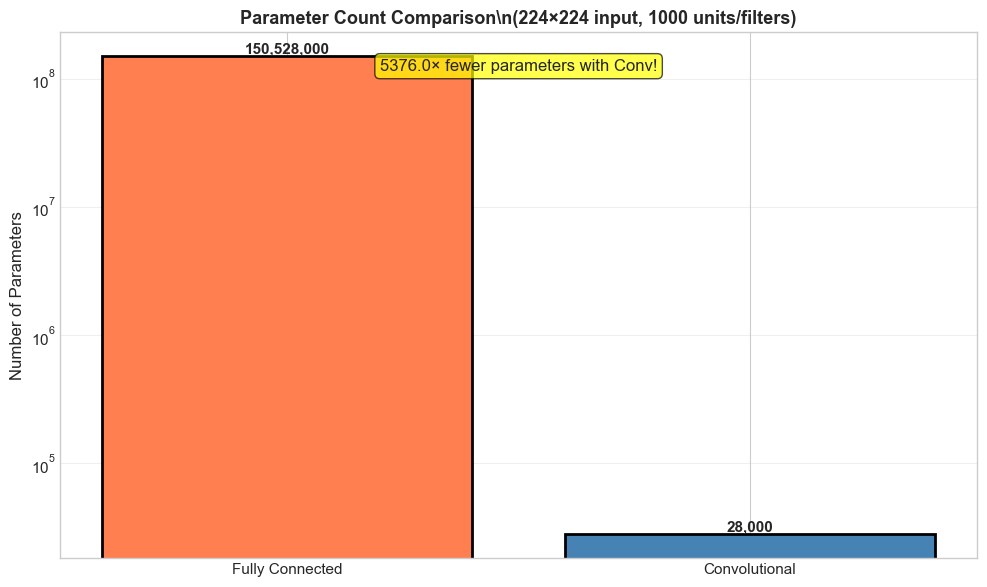

In [3]:
# Demonstrate the parameter explosion problem
print("=" * 70)
print("WHY NOT FULLY-CONNECTED NETWORKS FOR IMAGES?")
print("=" * 70)

# Typical image size
H, W, C = 224, 224, 3
n_pixels = H * W * C

print(f"\n📸 Input: {H}×{W}×{C} RGB image")
print(f"   Total pixels: {n_pixels:,}")

# FC layer with modest hidden units
n_hidden = 1000

# Calculate parameters
fc_params = n_pixels * n_hidden + n_hidden  # Weights + biases

print(f"\n🔢 Fully-Connected Layer ({n_hidden} hidden units):")
print(f"   Parameters: {fc_params:,}")
print(f"   Memory: ~{fc_params * 4 / 1e6:.1f} MB (float32)")

# Compare with convolutional layer
n_filters = 64
kernel_size = 3
conv_params = n_filters * (kernel_size * kernel_size * C + 1)

print(f"\n🔢 Convolutional Layer ({n_filters} filters, {kernel_size}×{kernel_size}):")
print(f"   Parameters: {conv_params:,}")
print(f"   Memory: ~{conv_params * 4 / 1e3:.1f} KB (float32)")

# Reduction factor
reduction = fc_params / conv_params

print(f"\n💡 Parameter Reduction: {reduction:.0f}× fewer with Conv!")
print(f"\n❌ Problems with FC for images:")
print(f"   1. Massive parameter count → overfitting")
print(f"   2. No spatial awareness: pixel (0,0) treated same as (100,100)")
print(f"   3. Ignores local patterns (edges, textures)")
print(f"   4. Not translation invariant")

# Visualize parameter comparison
fig, ax = plot_parameter_comparison(image_size=224, n_hidden=1000, figsize=(10, 6))
plt.show()

### The Key Insight

**Cracks look similar regardless of position in the image!**

We need two properties:
1. **Translation Invariance:** A crack at position (x,y) looks like a crack at (x',y')
2. **Parameter Sharing:** Use the same detector across all locations

**Solution:** Convolutional Neural Networks (CNNs)

---
## 3. 1D Convolution (Warmup)

Before tackling 2D images, let's understand convolution in 1D.

### Definition

For signal $x[n]$ and kernel $k[m]$:

$$(x * k)[n] = \sum_m x[n-m] \cdot k[m]$$

### CE Application: Smoothing Structural Vibration Signals

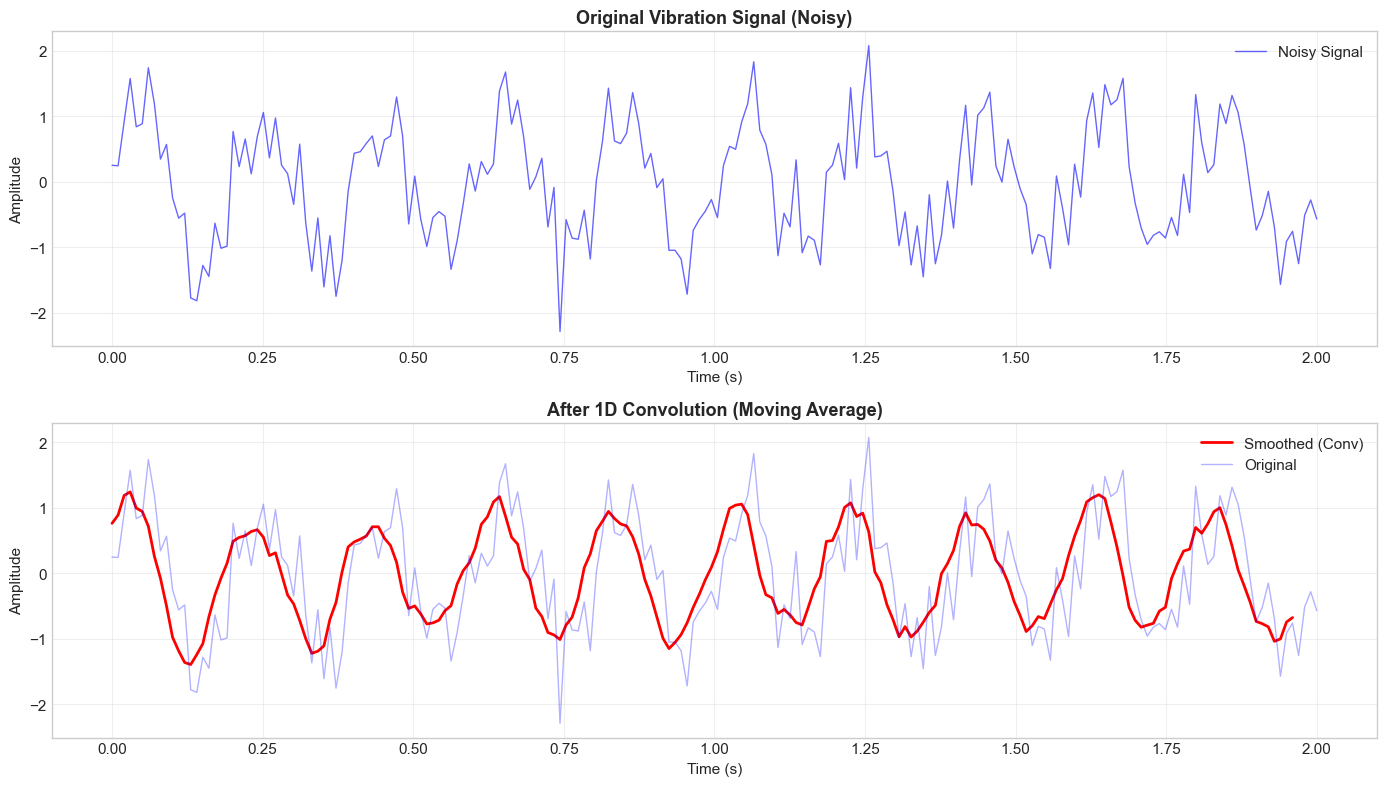


📊 1D Convolution Results:
   Input length: 200
   Kernel length: 5
   Output length: 196
   Formula: output_length = input_length - kernel_length + 1
            196 = 200 - 5 + 1 ✓


In [4]:
# Generate synthetic vibration signal
np.random.seed(42)
t = np.linspace(0, 2, 200)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.random.randn(len(t))

# Define smoothing kernel (moving average)
kernel_smooth = np.ones(5) / 5  # Average of 5 neighbors

# Apply 1D convolution
smoothed = conv1d(signal, kernel_smooth)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Original signal
ax = axes[0]
ax.plot(t, signal, 'b-', alpha=0.6, linewidth=1, label='Noisy Signal')
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Amplitude', fontsize=11)
ax.set_title('Original Vibration Signal (Noisy)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Smoothed signal
ax = axes[1]
t_smoothed = t[:len(smoothed)]
ax.plot(t_smoothed, smoothed, 'r-', linewidth=2, label='Smoothed (Conv)')
ax.plot(t, signal, 'b-', alpha=0.3, linewidth=1, label='Original')
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Amplitude', fontsize=11)
ax.set_title('After 1D Convolution (Moving Average)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 1D Convolution Results:")
print(f"   Input length: {len(signal)}")
print(f"   Kernel length: {len(kernel_smooth)}")
print(f"   Output length: {len(smoothed)}")
print(f"   Formula: output_length = input_length - kernel_length + 1")
print(f"            {len(smoothed)} = {len(signal)} - {len(kernel_smooth)} + 1 ✓")

### Key Observations

1. **Convolution is a sliding window operation**
2. **Kernel weights are shared** across all positions
3. **Output is smaller** than input (we'll fix this with padding)
4. **Different kernels detect different patterns** (smoothing, edge detection, etc.)

---
## 4. 2D Convolution

Now let's extend to 2D for images!

### Definition

For image $\mathbf{X} \in \mathbb{R}^{H \times W}$ and kernel $\mathbf{K} \in \mathbb{R}^{k \times k}$:

$$(\mathbf{X} * \mathbf{K})[i,j] = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} \mathbf{X}[i+m, j+n] \cdot \mathbf{K}[m,n]$$

### Worked Example: 5×5 Input, 3×3 Kernel

WORKED EXAMPLE: 2D CONVOLUTION (STEP-BY-STEP)

📥 Input X (5×5):
[[1. 2. 3. 0. 1.]
 [0. 1. 2. 3. 0.]
 [1. 0. 1. 2. 3.]
 [2. 1. 0. 1. 2.]
 [3. 2. 1. 0. 1.]]

🔧 Kernel K (3×3) - Vertical Edge Detector:
[[ 1.  0. -1.]
 [ 1.  0. -1.]
 [ 1.  0. -1.]]

📤 Output (3×3):
[[-4. -2.  2.]
 [ 0. -4. -2.]
 [ 4.  0. -4.]]

🧮 Manual Calculation for Output[0,0]:
   Window:
   [[1. 2. 3.]
 [0. 1. 2.]
 [1. 0. 1.]]

   Element-wise product with kernel:
   [[ 1.  0. -3.]
 [ 0.  0. -2.]
 [ 1.  0. -1.]]

   Sum: -4
   Output[0,0] = -4 ✓


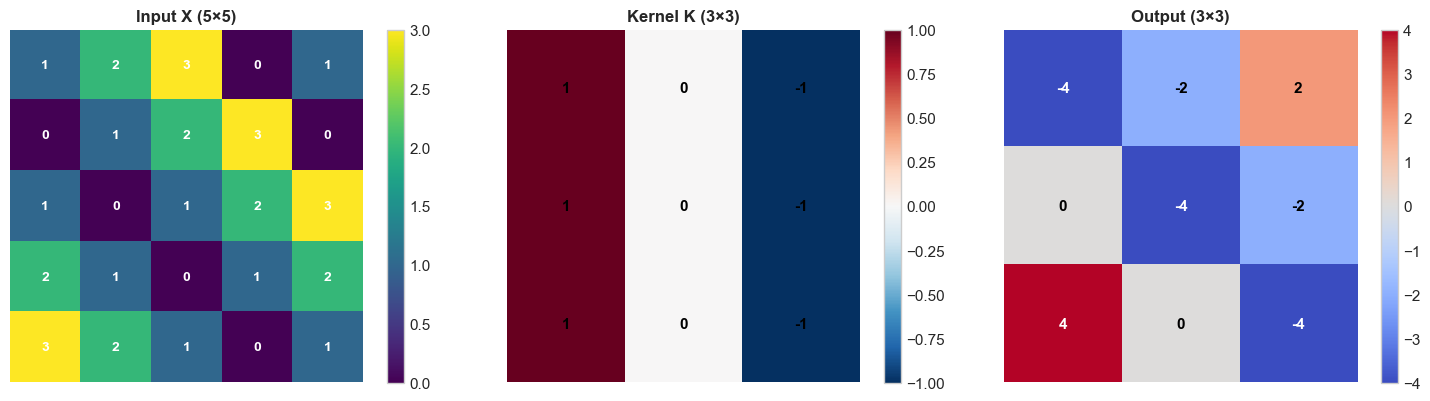

In [5]:
# Create the exact example from the slides
print("=" * 70)
print("WORKED EXAMPLE: 2D CONVOLUTION (STEP-BY-STEP)")
print("=" * 70)

# Input (from slides)
X = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 0],
    [1, 0, 1, 2, 3],
    [2, 1, 0, 1, 2],
    [3, 2, 1, 0, 1]
], dtype=np.float32)

# Kernel (vertical edge detector from slides)
K = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=np.float32)

print(f"\n📥 Input X (5×5):")
print(X)

print(f"\n🔧 Kernel K (3×3) - Vertical Edge Detector:")
print(K)

# Compute convolution
output = conv2d(X, K)

print(f"\n📤 Output (3×3):")
print(output)

# Manual calculation for position [0,0]
print(f"\n🧮 Manual Calculation for Output[0,0]:")
window = X[0:3, 0:3]
print(f"   Window:")
print(f"   {window}")
print(f"\n   Element-wise product with kernel:")
product = window * K
print(f"   {product}")
print(f"\n   Sum: {np.sum(product):.0f}")
print(f"   Output[0,0] = {output[0,0]:.0f} ✓")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Input
im0 = axes[0].imshow(X, cmap='viridis', vmin=0, vmax=3)
axes[0].set_title('Input X (5×5)', fontsize=12, fontweight='bold')
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        axes[0].text(j, i, f'{X[i,j]:.0f}', ha='center', va='center',
                    color='white', fontsize=10, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0])

# Kernel
im1 = axes[1].imshow(K, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title('Kernel K (3×3)', fontsize=12, fontweight='bold')
for i in range(K.shape[0]):
    for j in range(K.shape[1]):
        axes[1].text(j, i, f'{K[i,j]:.0f}', ha='center', va='center',
                    color='black', fontsize=11, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Output
im2 = axes[2].imshow(output, cmap='coolwarm')
axes[2].set_title('Output (3×3)', fontsize=12, fontweight='bold')
for i in range(output.shape[0]):
    for j in range(output.shape[1]):
        axes[2].text(j, i, f'{output[i,j]:.0f}', ha='center', va='center',
                    color='white' if abs(output[i,j]) > 2 else 'black',
                    fontsize=11, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

### Output Size Formula

For input size $H \times W$, kernel size $k \times k$, padding $p$, stride $s$:

$$\text{Output Height} = \left\lfloor \frac{H + 2p - k}{s} + 1 \right\rfloor$$

$$\text{Output Width} = \left\lfloor \frac{W + 2p - k}{s} + 1 \right\rfloor$$

**Example:** $5 \times 5$ input, $3 \times 3$ kernel, $p=0$, $s=1$:

$$\text{Output} = \left\lfloor \frac{5 + 0 - 3}{1} + 1 \right\rfloor = 3 \times 3$$

In [6]:
# Test output size formula
H_in, W_in = 5, 5
k = 3
p = 0
s = 1

H_out, W_out = output_size(H_in, W_in, k, p, s)

print(f"\n📐 Output Size Calculation:")
print(f"   Input: {H_in}×{W_in}")
print(f"   Kernel: {k}×{k}")
print(f"   Padding: {p}")
print(f"   Stride: {s}")
print(f"   Output: {H_out}×{W_out}")
print(f"   Actual output shape: {output.shape}")
print(f"   Formula matches! ✓")


📐 Output Size Calculation:
   Input: 5×5
   Kernel: 3×3
   Padding: 0
   Stride: 1
   Output: 3×3
   Actual output shape: (3, 3)
   Formula matches! ✓


### Common Kernels

Different kernels detect different features. Let's explore some common ones!


🔧 Common Convolution Kernels:
   Available: ['identity', 'blur', 'gaussian_blur', 'sharpen', 'edge_horizontal', 'edge_vertical', 'sobel_x', 'sobel_y', 'emboss', 'outline']


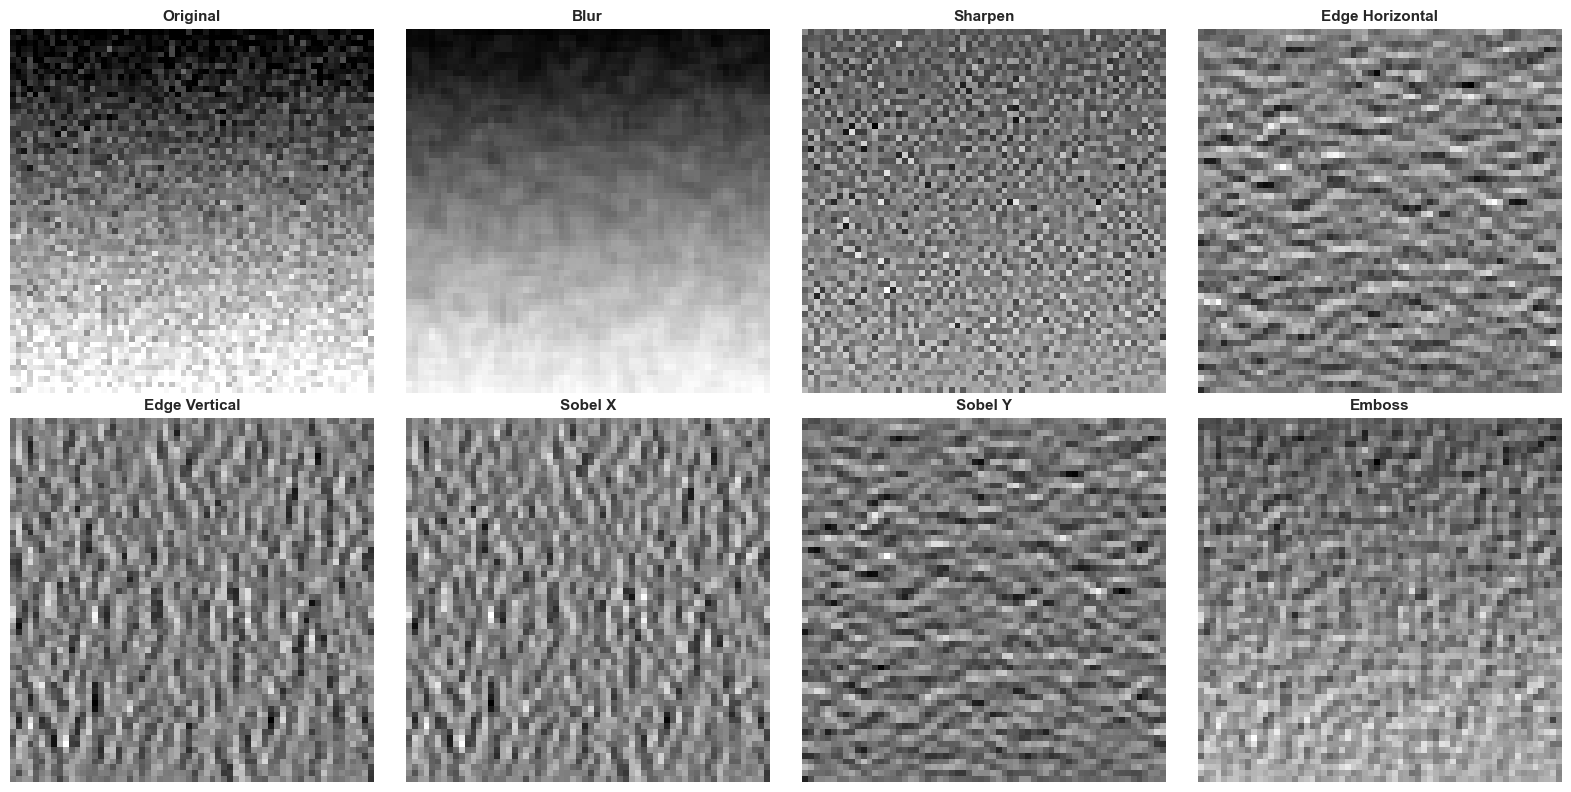


💡 Key Insight: Different kernels detect different features!
   • Blur: Smooths the image
   • Sharpen: Enhances edges
   • Edge detectors: Find boundaries
   • Sobel: Gradient-based edge detection
   • Emboss: 3D-like effect


In [7]:
# Get common kernels
kernels_dict = common_kernels()

print(f"\n🔧 Common Convolution Kernels:")
print(f"   Available: {list(kernels_dict.keys())}")

# Create a test image (simple gradient + noise)
np.random.seed(42)
test_image = np.linspace(0, 1, 64*64).reshape(64, 64)
test_image += np.random.randn(64, 64) * 0.1
test_image = np.clip(test_image, 0, 1)

# Apply different kernels
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Original
axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('Original', fontsize=11, fontweight='bold')
axes[0].axis('off')

# Apply kernels
kernel_names = ['blur', 'sharpen', 'edge_horizontal', 'edge_vertical',
               'sobel_x', 'sobel_y', 'emboss']

for i, name in enumerate(kernel_names):
    kernel = kernels_dict[name]
    result = conv2d(test_image, kernel)
    
    axes[i+1].imshow(result, cmap='gray')
    axes[i+1].set_title(name.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insight: Different kernels detect different features!")
print(f"   • Blur: Smooths the image")
print(f"   • Sharpen: Enhances edges")
print(f"   • Edge detectors: Find boundaries")
print(f"   • Sobel: Gradient-based edge detection")
print(f"   • Emboss: 3D-like effect")

---
## 5. Padding & Stride

### Problem: Convolution Shrinks Output

Without padding, each convolution reduces spatial dimensions.
After many layers, the image becomes too small!

### Solution: Padding

Add zeros around the border to preserve spatial dimensions.

**Types:**
- **Valid** (no padding): Output shrinks
- **Same** (zero padding): Output same size as input

PADDING DEMONSTRATION

📏 Input: (8, 8)
   Kernel: (3, 3)

📉 Valid Padding (p=0):
   Output: (6, 6)
   Size reduction: 8 → 6

📊 Same Padding (p=1):
   Output: (8, 8)
   Size preserved! ✓


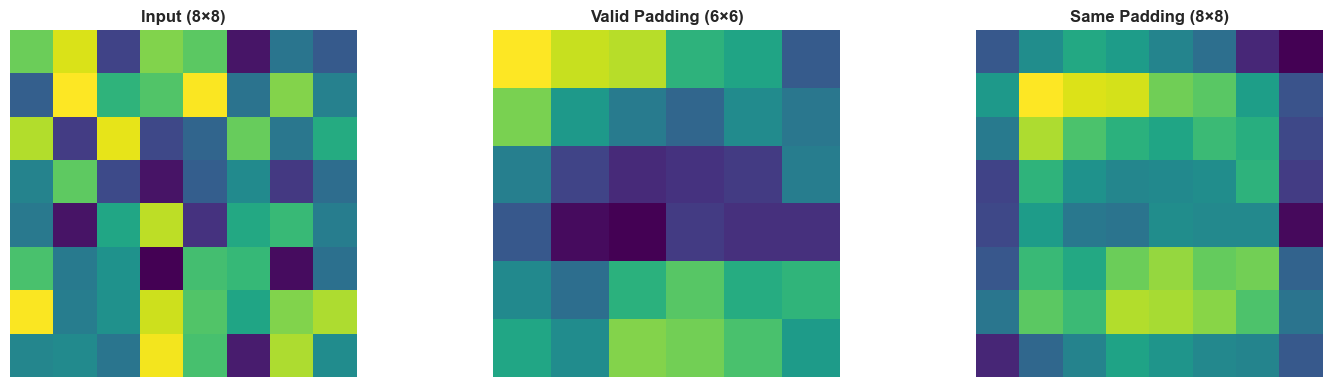

In [8]:
# Demonstrate padding
print("=" * 70)
print("PADDING DEMONSTRATION")
print("=" * 70)

# Create test image
image = np.random.rand(8, 8)
kernel = np.ones((3, 3)) / 9  # Average filter

# Valid padding (no padding)
output_valid = conv2d(image, kernel, padding=0)

# Same padding
p_same = (kernel.shape[0] - 1) // 2
output_same = conv2d(image, kernel, padding=p_same)

print(f"\n📏 Input: {image.shape}")
print(f"   Kernel: {kernel.shape}")
print(f"\n📉 Valid Padding (p=0):")
print(f"   Output: {output_valid.shape}")
print(f"   Size reduction: {image.shape[0]} → {output_valid.shape[0]}")

print(f"\n📊 Same Padding (p={p_same}):")
print(f"   Output: {output_same.shape}")
print(f"   Size preserved! ✓")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(image, cmap='viridis')
axes[0].set_title(f'Input ({image.shape[0]}×{image.shape[1]})',
                 fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(output_valid, cmap='viridis')
axes[1].set_title(f'Valid Padding ({output_valid.shape[0]}×{output_valid.shape[1]})',
                 fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(output_same, cmap='viridis')
axes[2].set_title(f'Same Padding ({output_same.shape[0]}×{output_same.shape[1]})',
                 fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Stride

**Stride** $s$: Number of pixels to skip when sliding the kernel.

- Stride = 1: Slide one pixel at a time (default)
- Stride > 1: Skip positions, downsample output

**Trade-off:** Fewer computations, but smaller spatial resolution.

STRIDE DEMONSTRATION

📐 Stride = 1:
   Output size: (14, 14)
   Formula: 14×14 ✓
   Reduction: 1.1×

📐 Stride = 2:
   Output size: (7, 7)
   Formula: 7×7 ✓
   Reduction: 2.3×

📐 Stride = 3:
   Output size: (5, 5)
   Formula: 5×5 ✓
   Reduction: 3.2×


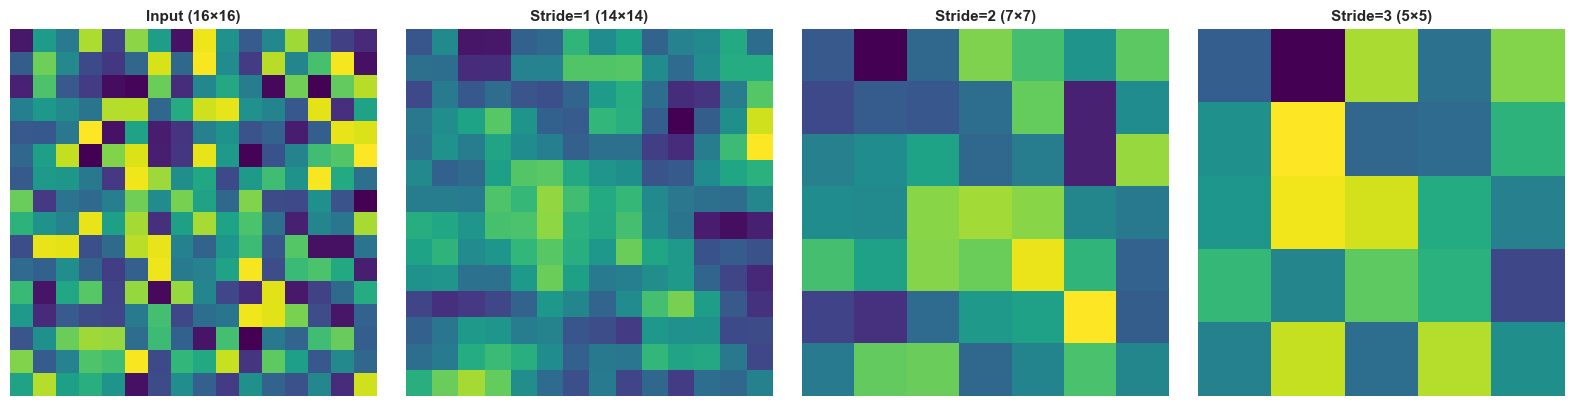


💡 Stride controls spatial resolution:
   • Larger stride = smaller output
   • Used for downsampling in deep networks


In [9]:
# Demonstrate stride
print("=" * 70)
print("STRIDE DEMONSTRATION")
print("=" * 70)

# Test different strides
image = np.random.rand(16, 16)
kernel = np.ones((3, 3)) / 9

strides = [1, 2, 3]
outputs = []

for s in strides:
    output = conv2d(image, kernel, padding=0, stride=s)
    outputs.append(output)
    
    H_out, W_out = output_size(16, 16, 3, 0, s)
    print(f"\n📐 Stride = {s}:")
    print(f"   Output size: {output.shape}")
    print(f"   Formula: {H_out}×{W_out} ✓")
    print(f"   Reduction: {16/output.shape[0]:.1f}×")

# Visualize
fig, axes = plt.subplots(1, len(strides) + 1, figsize=(16, 4))

axes[0].imshow(image, cmap='viridis')
axes[0].set_title(f'Input (16×16)', fontsize=11, fontweight='bold')
axes[0].axis('off')

for i, (s, output) in enumerate(zip(strides, outputs)):
    axes[i+1].imshow(output, cmap='viridis')
    axes[i+1].set_title(f'Stride={s} ({output.shape[0]}×{output.shape[1]})',
                       fontsize=11, fontweight='bold')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n💡 Stride controls spatial resolution:")
print(f"   • Larger stride = smaller output")
print(f"   • Used for downsampling in deep networks")

### Interactive Widget: Explore Convolution Parameters

Try different combinations of kernel, padding, and stride!

In [11]:
# Interactive convolution widget
# Uncomment to run in Jupyter/Colab:
conv2d_widget()

print("🎮 Interactive Convolution Explorer")
print("=" * 50)
print("Run conv2d_widget() in Jupyter/Colab to explore:")
print("  • Different kernels (edge detection, blur, etc.)")
print("  • Padding (0, 1, 2, 3)")
print("  • Stride (1, 2, 3, 4)")
print("\nSee live output shape and visual results!")

interactive(children=(Dropdown(description='Kernel:', options=('identity', 'blur', 'gaussian_blur', 'sharpen',…

🎮 Interactive Convolution Explorer
Run conv2d_widget() in Jupyter/Colab to explore:
  • Different kernels (edge detection, blur, etc.)
  • Padding (0, 1, 2, 3)
  • Stride (1, 2, 3, 4)

See live output shape and visual results!


---
## 5. Multiple Channels & Filters

Real images have multiple channels (RGB), and we want to detect multiple features!

### Multi-Channel Convolution

For RGB image $\mathbf{X} \in \mathbb{R}^{H \times W \times 3}$ and filter $\mathbf{K} \in \mathbb{R}^{k \times k \times 3}$:

$$\text{Output}[i,j] = \sum_{c=1}^{3} \sum_{m,n} \mathbf{X}[i+m, j+n, c] \cdot \mathbf{K}[m,n,c]$$

**Key:** Convolution sums over **all input channels**.

### Multiple Filters

With $F$ filters, output has $F$ channels (feature maps):

$$\mathbf{Y} \in \mathbb{R}^{H' \times W' \times F}$$

Each filter learns to detect a different feature!

MULTI-CHANNEL CONVOLUTION

📥 Input: (32, 32, 3) (RGB image)
🔧 Filters: (16, 3, 3, 3)
   • 16 filters
   • Each filter: 3×3×3

📤 Output: (32, 32, 16)
   • Spatial dims preserved (same padding)
   • 16 feature maps (one per filter)


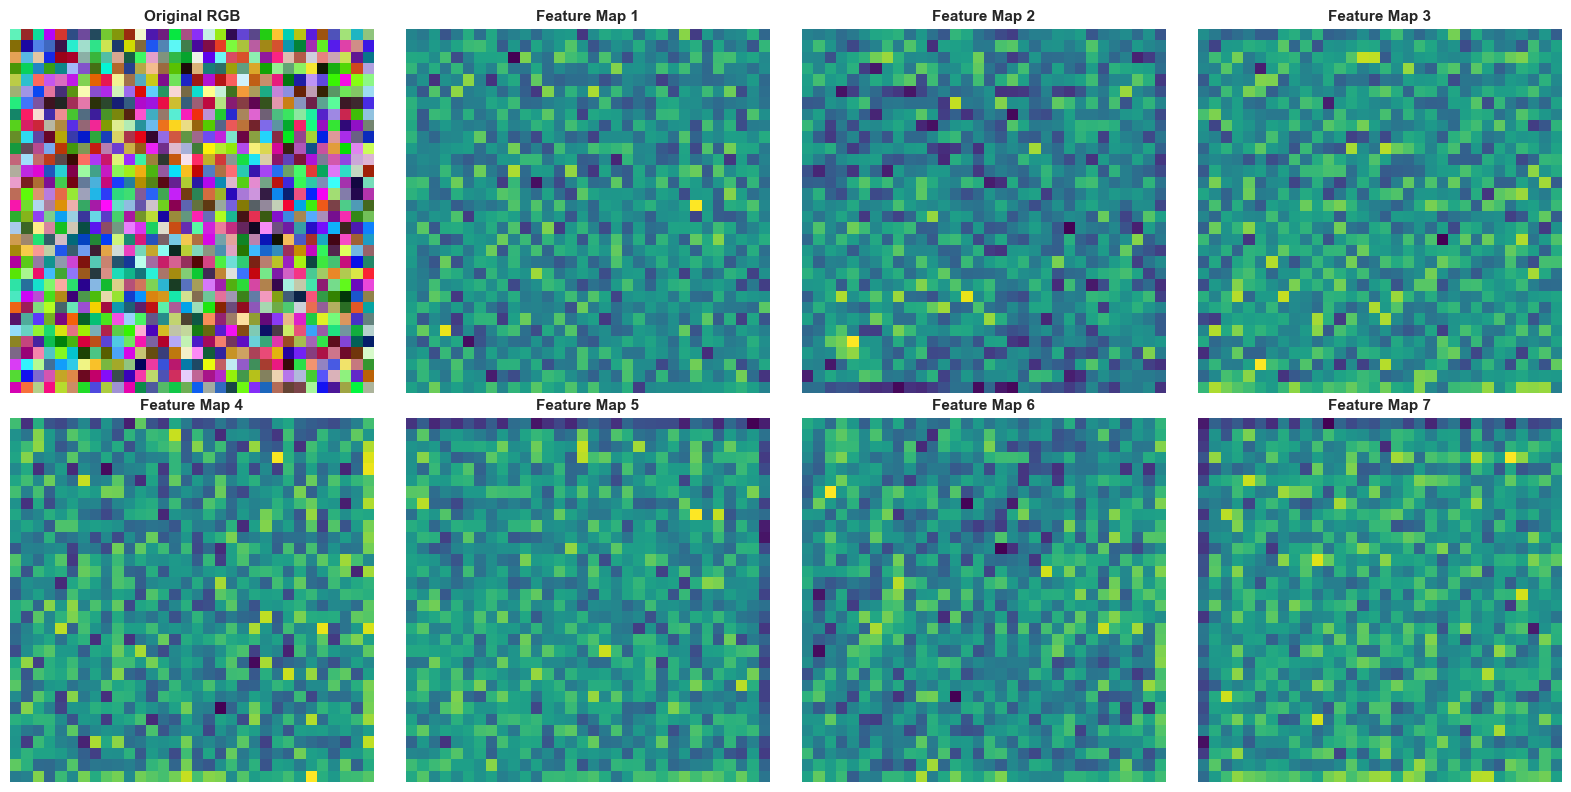


💡 Each feature map highlights different patterns!
   • Filter 1 might detect horizontal edges
   • Filter 2 might detect vertical edges
   • Filter 3 might detect textures
   • ... and so on


In [12]:
# Demonstrate multi-channel convolution
print("=" * 70)
print("MULTI-CHANNEL CONVOLUTION")
print("=" * 70)

# Create RGB image
np.random.seed(42)
rgb_image = np.random.rand(32, 32, 3).astype(np.float32)

# Create multiple filters
n_filters = 16
kernel_size = 3
kernels = np.random.randn(n_filters, kernel_size, kernel_size, 3).astype(np.float32) * 0.1

print(f"\n📥 Input: {rgb_image.shape} (RGB image)")
print(f"🔧 Filters: {kernels.shape}")
print(f"   • {n_filters} filters")
print(f"   • Each filter: {kernel_size}×{kernel_size}×3")

# Apply multi-channel convolution
output_multi = conv2d_multichannel(rgb_image, kernels, padding=1, stride=1)

print(f"\n📤 Output: {output_multi.shape}")
print(f"   • Spatial dims preserved (same padding)")
print(f"   • {n_filters} feature maps (one per filter)")

# Visualize some feature maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Original RGB
axes[0].imshow(rgb_image)
axes[0].set_title('Original RGB', fontsize=11, fontweight='bold')
axes[0].axis('off')

# Show first 7 feature maps
for i in range(7):
    axes[i+1].imshow(output_multi[:, :, i], cmap='viridis')
    axes[i+1].set_title(f'Feature Map {i+1}', fontsize=11, fontweight='bold')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n💡 Each feature map highlights different patterns!")
print(f"   • Filter 1 might detect horizontal edges")
print(f"   • Filter 2 might detect vertical edges")
print(f"   • Filter 3 might detect textures")
print(f"   • ... and so on")

### Parameter Counting

For a convolutional layer with:
- $F$ filters
- Kernel size $k \times k$
- $C_{in}$ input channels

**Parameters:**

$$\text{Params} = F \times (k \times k \times C_{in} + 1)$$

The $+1$ is for the bias term (one per filter).

**Example:** 32 filters, $3 \times 3$ kernel, 3 input channels:

$$\text{Params} = 32 \times (3 \times 3 \times 3 + 1) = 32 \times 28 = 896$$

Much smaller than a fully-connected layer!

In [13]:
# Parameter counting example
F = 32
k = 3
C_in = 3

params_conv = F * (k * k * C_in + 1)

print(f"\n🔢 Convolutional Layer Parameters:")
print(f"   Filters: {F}")
print(f"   Kernel size: {k}×{k}")
print(f"   Input channels: {C_in}")
print(f"   Parameters: {params_conv:,}")

# Compare with FC layer
H, W = 224, 224
params_fc = (H * W * C_in) * F

print(f"\n🔢 Fully-Connected Layer (same input/output):")
print(f"   Input: {H}×{W}×{C_in}")
print(f"   Output: {F} units")
print(f"   Parameters: {params_fc:,}")

print(f"\n💡 Reduction: {params_fc / params_conv:.0f}× fewer parameters with Conv!")


🔢 Convolutional Layer Parameters:
   Filters: 32
   Kernel size: 3×3
   Input channels: 3
   Parameters: 896

🔢 Fully-Connected Layer (same input/output):
   Input: 224×224×3
   Output: 32 units
   Parameters: 4,816,896

💡 Reduction: 5376× fewer parameters with Conv!


---

**End of Part 3 (Sections 1-5)**

We've covered:
✅ Setup and imports  
✅ Motivation: Why CNNs for images?  
✅ 1D Convolution warmup  
✅ 2D Convolution with worked example  
✅ Padding and stride  
✅ Multiple channels and filters  

**Next:** Pooling, CNN architecture, and modern architectures (LeNet, VGG, ResNet)

---

---
## 6. Pooling Operations

After convolution + ReLU, we often apply **pooling** to:
1. Reduce spatial dimensions (fewer parameters, less computation)
2. Provide translation invariance
3. Increase receptive field

### Types of Pooling

**Max Pooling:** Take maximum value in each window

$$\text{Output}[i,j] = \max_{m,n \in \text{window}} \mathbf{X}[i \cdot s + m, j \cdot s + n]$$

**Average Pooling:** Take mean value in each window

$$\text{Output}[i,j] = \frac{1}{k^2} \sum_{m,n \in \text{window}} \mathbf{X}[i \cdot s + m, j \cdot s + n]$$

POOLING DEMONSTRATION

📥 Input Feature Map (8×8):
[[3 9 7 5 1 1 0 8]
 [6 7 0 9 8 2 1 1]
 [3 5 4 2 6 1 2 3]
 [4 7 1 5 5 0 6 1]
 [0 9 9 8 3 0 6 4]
 [1 4 0 9 2 6 3 5]
 [5 1 9 7 9 8 5 9]
 [0 1 0 3 3 2 8 3]]

📤 Max Pooling (2×2, stride=2):
[[9 9 8 8]
 [7 5 6 6]
 [9 9 6 6]
 [5 9 9 9]]
   Output shape: (4, 4)

📤 Average Pooling (2×2, stride=2):
[[6 5 3 3]
 [5 3 3 3]
 [4 6 3 4]
 [2 5 6 6]]
   Output shape: (4, 4)


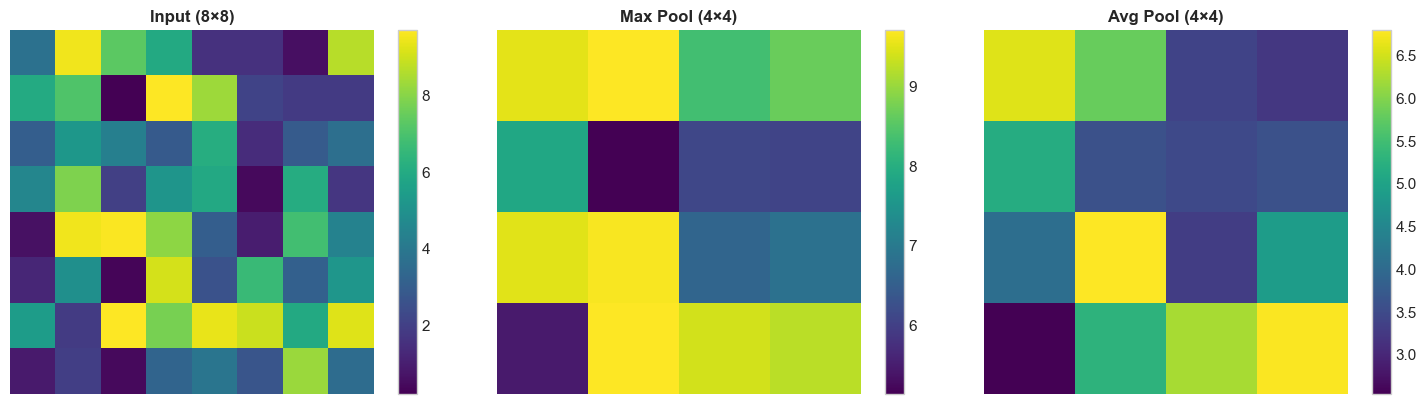

In [14]:
# Demonstrate pooling
print("=" * 70)
print("POOLING DEMONSTRATION")
print("=" * 70)

# Create test feature map
np.random.seed(42)
feature_map = np.random.rand(8, 8) * 10

print(f"\n📥 Input Feature Map (8×8):")
print(feature_map.astype(int))

# Apply max pooling
max_pooled = max_pool2d(feature_map, pool_size=2, stride=2)

print(f"\n📤 Max Pooling (2×2, stride=2):")
print(max_pooled.astype(int))
print(f"   Output shape: {max_pooled.shape}")

# Apply average pooling
avg_pooled = avg_pool2d(feature_map, pool_size=2, stride=2)

print(f"\n📤 Average Pooling (2×2, stride=2):")
print(avg_pooled.astype(int))
print(f"   Output shape: {avg_pooled.shape}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
im0 = axes[0].imshow(feature_map, cmap='viridis')
axes[0].set_title('Input (8×8)', fontsize=12, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0])

# Max pooled
im1 = axes[1].imshow(max_pooled, cmap='viridis')
axes[1].set_title('Max Pool (4×4)', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Avg pooled
im2 = axes[2].imshow(avg_pooled, cmap='viridis')
axes[2].set_title('Avg Pool (4×4)', fontsize=12, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

### Why Pooling?

1. **Reduces parameters:** Smaller feature maps = fewer computations
2. **Translation invariance:** Small shifts in input don't change output much
3. **Increases receptive field:** Each neuron "sees" a larger region

**Intuition:** "I care *that* a feature exists, not *exactly where* it is."

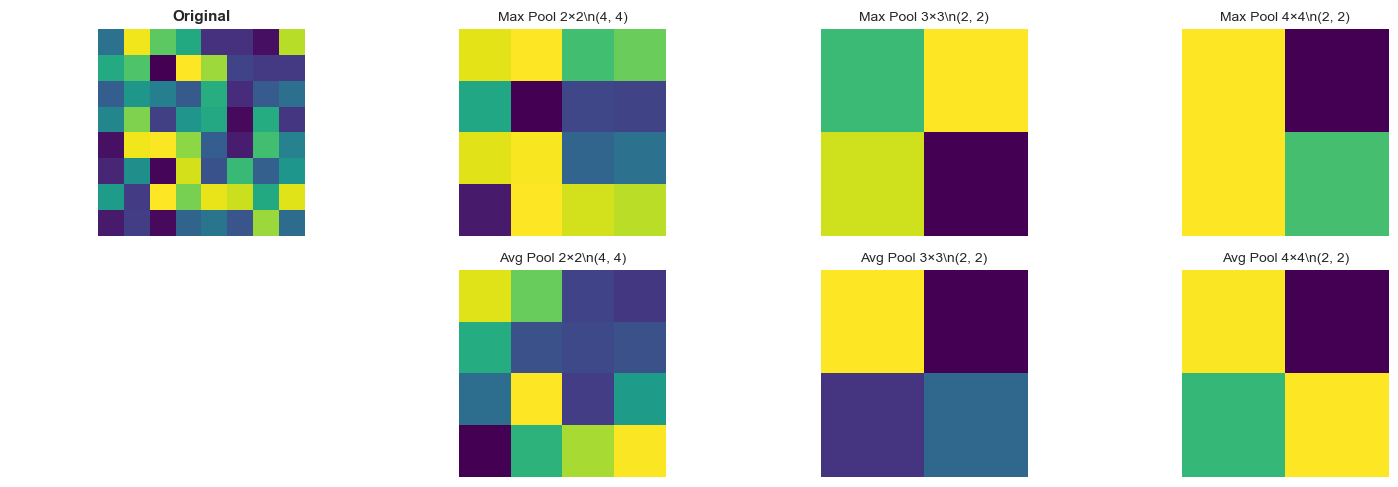


💡 Larger pool size = more aggressive downsampling
   • 2×2: Halves dimensions
   • 3×3: Reduces by ~3×
   • 4×4: Reduces by 4×


In [15]:
# Compare different pool sizes
fig, axes = plot_pooling_comparison(feature_map, pool_sizes=[2, 3, 4], figsize=(15, 5))
plt.show()

print(f"\n💡 Larger pool size = more aggressive downsampling")
print(f"   • 2×2: Halves dimensions")
print(f"   • 3×3: Reduces by ~3×")
print(f"   • 4×4: Reduces by 4×")

### Interactive Widget: Explore Pooling

Try different pool sizes and modes!

In [16]:
# Interactive pooling widget
# Uncomment to run in Jupyter/Colab:
pooling_widget()

print("🎮 Interactive Pooling Explorer")
print("=" * 50)
print("Run pooling_widget() in Jupyter/Colab to explore:")
print("  • Pool size (2, 3, 4)")
print("  • Stride (1, 2, 3, 4)")
print("  • Mode (max vs avg)")
print("\nSee how pooling affects spatial dimensions!")

interactive(children=(IntSlider(value=2, description='Pool Size:', max=4, min=2), IntSlider(value=2, descripti…

🎮 Interactive Pooling Explorer
Run pooling_widget() in Jupyter/Colab to explore:
  • Pool size (2, 3, 4)
  • Stride (1, 2, 3, 4)
  • Mode (max vs avg)

See how pooling affects spatial dimensions!


---
## 7. CNN Architecture: Putting It Together

### Typical CNN Architecture

$$\text{Input} \to [\text{Conv} \to \text{ReLU} \to \text{Pool}]^n \to \text{Flatten} \to \text{FC} \to \text{Output}$$

**Components:**
1. **Convolutional layers:** Extract spatial features
2. **Activation (ReLU):** Introduce nonlinearity
3. **Pooling layers:** Downsample
4. **Fully connected layers:** Final classification/regression

### What Happens at Each Stage?

- **Early layers:** Low-level features (edges, gradients, textures)
- **Middle layers:** Mid-level features (patterns, shapes, parts)
- **Deep layers:** High-level concepts (objects, cracks, specific patterns)

In [17]:
# Demonstrate a simple CNN forward pass (manually)
print("=" * 70)
print("CNN FORWARD PASS (MANUAL DEMONSTRATION)")
print("=" * 70)

# Create synthetic input image
np.random.seed(42)
input_image = np.random.rand(32, 32, 3).astype(np.float32)

print(f"\n📥 Input: {input_image.shape} (RGB image)")

# Layer 1: Conv + ReLU + Pool
print(f"\n🔧 Layer 1: Conv(16 filters, 3×3) + ReLU + MaxPool(2×2)")
kernels_1 = np.random.randn(16, 3, 3, 3).astype(np.float32) * 0.1
conv1 = conv2d_multichannel(input_image, kernels_1, padding=1, stride=1)
relu1 = np.maximum(0, conv1)  # ReLU
pool1 = max_pool2d(relu1, pool_size=2, stride=2)
print(f"   After Conv: {conv1.shape}")
print(f"   After ReLU: {relu1.shape}")
print(f"   After Pool: {pool1.shape}")

# Layer 2: Conv + ReLU + Pool
print(f"\n🔧 Layer 2: Conv(32 filters, 3×3) + ReLU + MaxPool(2×2)")
kernels_2 = np.random.randn(32, 3, 3, 16).astype(np.float32) * 0.1
conv2 = conv2d_multichannel(pool1, kernels_2, padding=1, stride=1)
relu2 = np.maximum(0, conv2)
pool2 = max_pool2d(relu2, pool_size=2, stride=2)
print(f"   After Conv: {conv2.shape}")
print(f"   After ReLU: {relu2.shape}")
print(f"   After Pool: {pool2.shape}")

# Flatten
print(f"\n🔧 Flatten:")
flattened = pool2.reshape(-1)
print(f"   Shape: {flattened.shape}")

# Fully connected (simulated)
n_classes = 10
fc_weights = np.random.randn(flattened.shape[0], n_classes).astype(np.float32) * 0.1
output = flattened @ fc_weights
print(f"\n🔧 Fully Connected ({n_classes} classes):")
print(f"   Output: {output.shape}")

print(f"\n✅ Forward pass complete!")
print(f"\n📊 Summary:")
print(f"   Input:  32×32×3")
print(f"   Conv1:  32×32×16  (same padding)")
print(f"   Pool1:  16×16×16  (2× downsample)")
print(f"   Conv2:  16×16×32  (same padding)")
print(f"   Pool2:  8×8×32    (2× downsample)")
print(f"   Flatten: {flattened.shape[0]}")
print(f"   Output: {n_classes} classes")

CNN FORWARD PASS (MANUAL DEMONSTRATION)

📥 Input: (32, 32, 3) (RGB image)

🔧 Layer 1: Conv(16 filters, 3×3) + ReLU + MaxPool(2×2)
   After Conv: (32, 32, 16)
   After ReLU: (32, 32, 16)
   After Pool: (16, 16, 16)

🔧 Layer 2: Conv(32 filters, 3×3) + ReLU + MaxPool(2×2)
   After Conv: (16, 16, 32)
   After ReLU: (16, 16, 32)
   After Pool: (8, 8, 32)

🔧 Flatten:
   Shape: (2048,)

🔧 Fully Connected (10 classes):
   Output: (10,)

✅ Forward pass complete!

📊 Summary:
   Input:  32×32×3
   Conv1:  32×32×16  (same padding)
   Pool1:  16×16×16  (2× downsample)
   Conv2:  16×16×32  (same padding)
   Pool2:  8×8×32    (2× downsample)
   Flatten: 2048
   Output: 10 classes


### Visualizing CNN Architecture

Let's visualize how spatial dimensions change through the network.

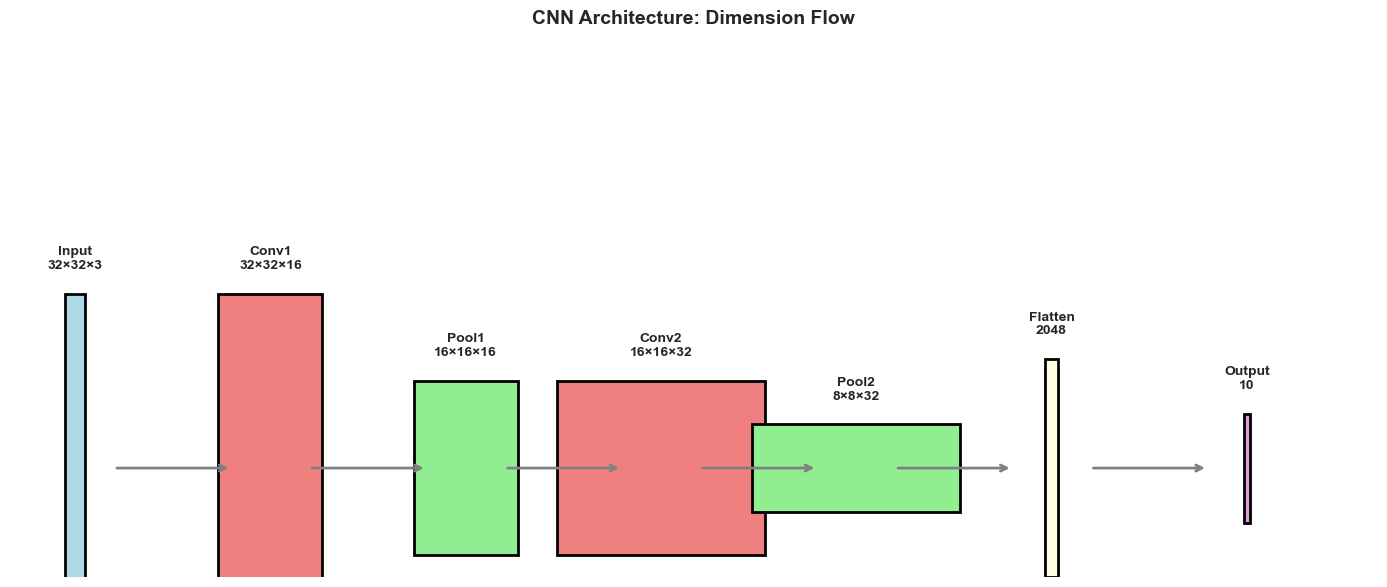


💡 Observations:
   • Spatial dimensions decrease (32 → 16 → 8)
   • Number of channels increases (3 → 16 → 32)
   • Final flatten creates a vector for classification


In [18]:
# Visualize dimension flow
fig, ax = plt.subplots(figsize=(14, 6))

# Architecture stages
stages = [
    {'name': 'Input\n32×32×3', 'x': 0, 'h': 32, 'w': 3, 'color': 'lightblue'},
    {'name': 'Conv1\n32×32×16', 'x': 1.5, 'h': 32, 'w': 16, 'color': 'lightcoral'},
    {'name': 'Pool1\n16×16×16', 'x': 3, 'h': 16, 'w': 16, 'color': 'lightgreen'},
    {'name': 'Conv2\n16×16×32', 'x': 4.5, 'h': 16, 'w': 32, 'color': 'lightcoral'},
    {'name': 'Pool2\n8×8×32', 'x': 6, 'h': 8, 'w': 32, 'color': 'lightgreen'},
    {'name': 'Flatten\n2048', 'x': 7.5, 'h': 20, 'w': 2, 'color': 'lightyellow'},
    {'name': 'Output\n10', 'x': 9, 'h': 10, 'w': 1, 'color': 'plum'}
]

# Draw boxes
for stage in stages:
    # Scale for visualization
    h_scaled = stage['h'] / 2
    w_scaled = stage['w'] / 2
    
    rect = plt.Rectangle((stage['x'] - w_scaled/20, 5 - h_scaled/2),
                         w_scaled/10, h_scaled,
                         facecolor=stage['color'], edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    
    ax.text(stage['x'], 5 + h_scaled/2 + 1, stage['name'],
           ha='center', va='bottom', fontsize=10, fontweight='bold')

# Draw arrows
for i in range(len(stages) - 1):
    ax.annotate('', xy=(stages[i+1]['x'] - 0.3, 5), xytext=(stages[i]['x'] + 0.3, 5),
               arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

ax.set_xlim(-0.5, 10)
ax.set_ylim(0, 25)
ax.axis('off')
ax.set_title('CNN Architecture: Dimension Flow', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Observations:")
print(f"   • Spatial dimensions decrease (32 → 16 → 8)")
print(f"   • Number of channels increases (3 → 16 → 32)")
print(f"   • Final flatten creates a vector for classification")

---
## 8. Feature Hierarchy: What Each Layer Learns

CNNs learn a **hierarchy of increasingly abstract features**:

- **Layer 1:** Edges, gradients, simple textures
- **Layer 2-3:** Patterns, shapes, object parts
- **Layer 4+:** High-level concepts, complete objects

This is analogous to the visual cortex in the human brain!

FEATURE HIERARCHY IN CNNs

🔍 Early Layers: Low-level features
   • Horizontal edges, vertical edges, diagonals

🔍 Middle Layers: Mid-level features
   • Corners, curves, textures, patterns

🔍 Deep Layers: High-level concepts
   • Object parts, specific textures, semantic features


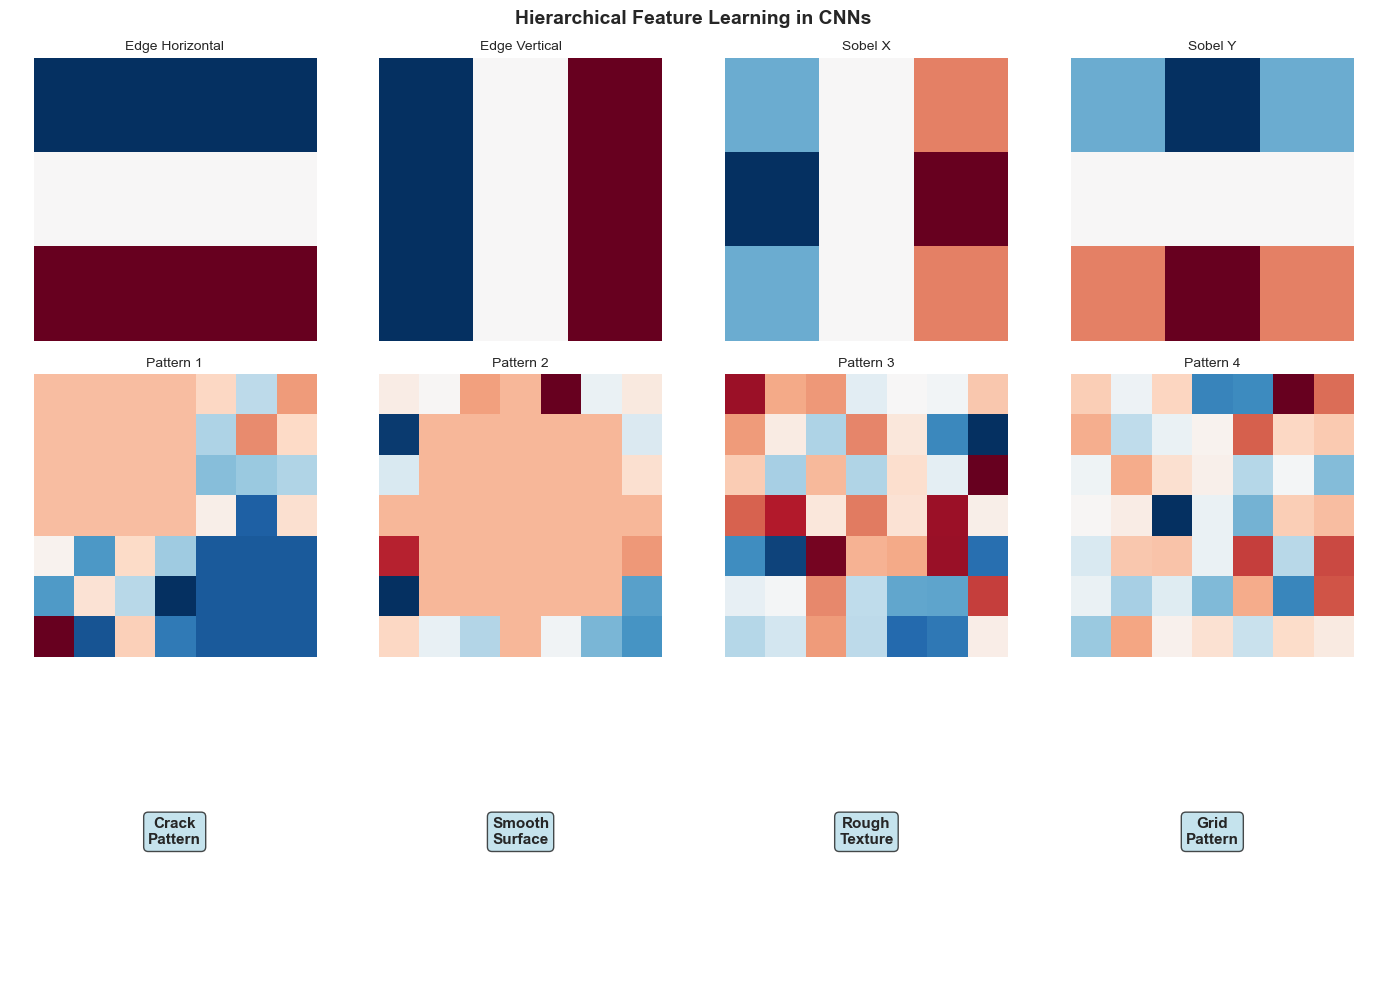


💡 This hierarchy is learned automatically during training!
   We don't manually design these features — the network discovers them.


In [19]:
# Demonstrate feature hierarchy with synthetic examples
print("=" * 70)
print("FEATURE HIERARCHY IN CNNs")
print("=" * 70)

# Create synthetic "learned" filters for each layer
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

# Early layer filters (edges, gradients)
print(f"\n🔍 Early Layers: Low-level features")
kernels_early = common_kernels()
early_names = ['edge_horizontal', 'edge_vertical', 'sobel_x', 'sobel_y']

for i, name in enumerate(early_names):
    axes[0, i].imshow(kernels_early[name], cmap='RdBu_r')
    axes[0, i].set_title(name.replace('_', ' ').title(), fontsize=10)
    axes[0, i].axis('off')

axes[0, 0].set_ylabel('Early Layers\n(Edges)', fontsize=11, fontweight='bold')

# Mid layer filters (patterns - simulated)
print(f"   • Horizontal edges, vertical edges, diagonals")
print(f"\n🔍 Middle Layers: Mid-level features")
print(f"   • Corners, curves, textures, patterns")

for i in range(4):
    # Simulate mid-level patterns
    pattern = np.random.randn(7, 7)
    if i == 0:  # Corner
        pattern[:4, :4] = 1
        pattern[4:, 4:] = -1
    elif i == 1:  # Circle
        y, x = np.ogrid[-3:4, -3:4]
        mask = x**2 + y**2 <= 9
        pattern[mask] = 1
    
    axes[1, i].imshow(pattern, cmap='RdBu_r')
    axes[1, i].set_title(f'Pattern {i+1}', fontsize=10)
    axes[1, i].axis('off')

axes[1, 0].set_ylabel('Middle Layers\n(Patterns)', fontsize=11, fontweight='bold')

# Deep layer filters (high-level - conceptual)
print(f"\n🔍 Deep Layers: High-level concepts")
print(f"   • Object parts, specific textures, semantic features")

concepts = ['Crack\nPattern', 'Smooth\nSurface', 'Rough\nTexture', 'Grid\nPattern']
for i, concept in enumerate(concepts):
    # Conceptual representation
    axes[2, i].text(0.5, 0.5, concept, ha='center', va='center',
                   fontsize=11, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    axes[2, i].set_xlim(0, 1)
    axes[2, i].set_ylim(0, 1)
    axes[2, i].axis('off')

axes[2, 0].set_ylabel('Deep Layers\n(Concepts)', fontsize=11, fontweight='bold')

plt.suptitle('Hierarchical Feature Learning in CNNs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n💡 This hierarchy is learned automatically during training!")
print(f"   We don't manually design these features — the network discovers them.")

### Receptive Field

The **receptive field** of a neuron is the region of the input that affects it.

With each layer, the receptive field grows:
- After 1 conv layer (3×3): 3×3 receptive field
- After 2 conv layers: 5×5 receptive field
- After 3 conv layers: 7×7 receptive field

**Pooling also increases receptive field!**

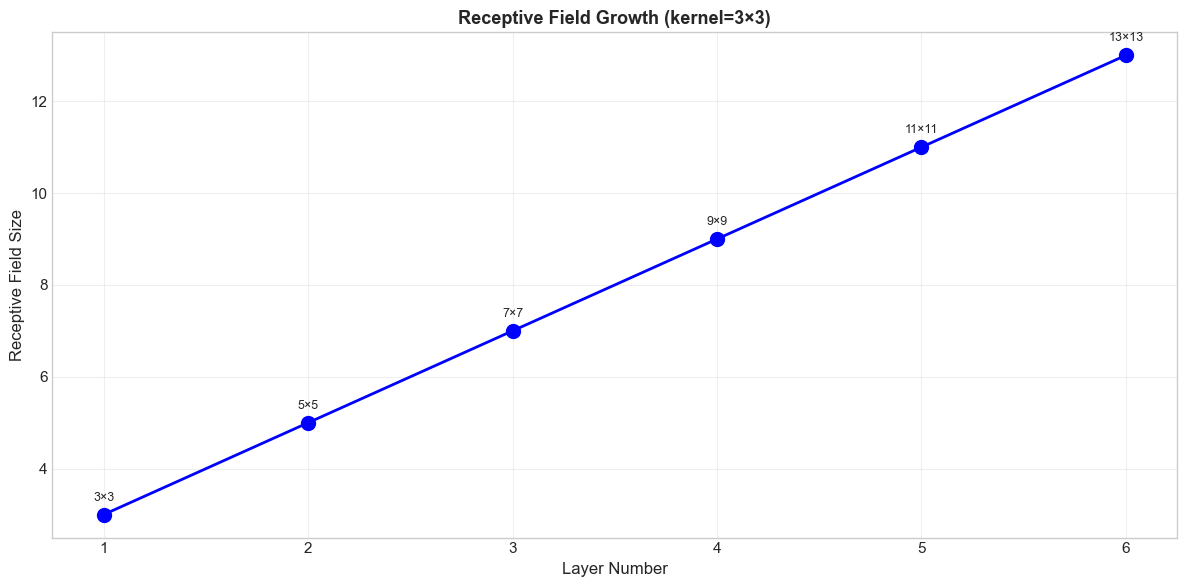


💡 Deeper networks see larger regions of the input!
   This is why deep CNNs can recognize complex patterns.


In [20]:
# Visualize receptive field growth
fig, ax = plot_receptive_field(n_layers=6, kernel_size=3, figsize=(12, 6))
plt.show()

print(f"\n💡 Deeper networks see larger regions of the input!")
print(f"   This is why deep CNNs can recognize complex patterns.")

---
## 9. Parameter Counting Deep Dive

Let's count parameters in a realistic CNN and compare with FC.

### Example: SimpleCNN for 32×32 images

PARAMETER COUNTING: SimpleCNN

🏗️ Architecture:
   Input: 32×32×3
   Conv1: 16 filters, 3×3, padding=1
   Pool1: 2×2
   Conv2: 32 filters, 3×3, padding=1
   Pool2: 2×2
   FC1: 128 units
   FC2: 10 units (output)

🔢 Parameter Counting:
   Conv1: 16 × (3×3×3 + 1) = 448
   Conv2: 32 × (3×3×16 + 1) = 4,640
   FC1: 2048 × 128 + 128 = 262,272
   FC2: 128 × 10 + 10 = 1,290

   Total: 268,650

🔢 All-FC Network (same input/output):
   FC1: 3072 × 128 + 128 = 393,344
   FC2: 128 × 10 + 10 = 1,290
   Total: 394,634

💡 CNN has 1.5× fewer parameters!
   Yet CNNs perform BETTER on image tasks due to:
   • Spatial structure awareness
   • Translation invariance
   • Hierarchical feature learning


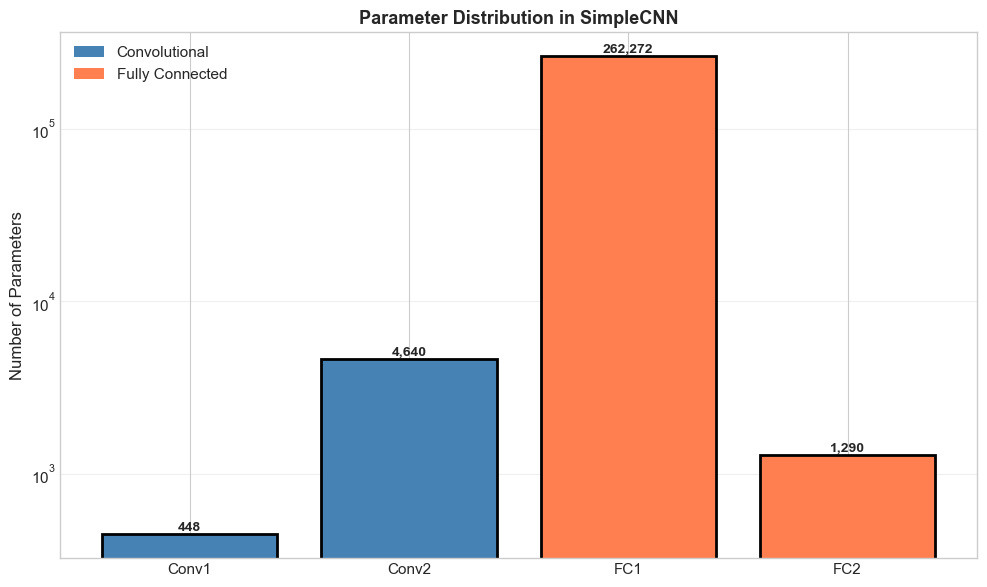


💡 Most parameters are in the FC layers!
   Modern CNNs minimize FC layers (e.g., use global avg pooling)


In [21]:
# Parameter counting for SimpleCNN
print("=" * 70)
print("PARAMETER COUNTING: SimpleCNN")
print("=" * 70)

# Architecture
print(f"\n🏗️ Architecture:")
print(f"   Input: 32×32×3")
print(f"   Conv1: 16 filters, 3×3, padding=1")
print(f"   Pool1: 2×2")
print(f"   Conv2: 32 filters, 3×3, padding=1")
print(f"   Pool2: 2×2")
print(f"   FC1: 128 units")
print(f"   FC2: 10 units (output)")

# Count parameters
print(f"\n🔢 Parameter Counting:")

# Conv1
conv1_params = 16 * (3 * 3 * 3 + 1)
print(f"   Conv1: 16 × (3×3×3 + 1) = {conv1_params:,}")

# Conv2
conv2_params = 32 * (3 * 3 * 16 + 1)
print(f"   Conv2: 32 × (3×3×16 + 1) = {conv2_params:,}")

# FC1 (input is 8×8×32 after two pools)
fc1_input = 8 * 8 * 32
fc1_params = fc1_input * 128 + 128
print(f"   FC1: {fc1_input} × 128 + 128 = {fc1_params:,}")

# FC2
fc2_params = 128 * 10 + 10
print(f"   FC2: 128 × 10 + 10 = {fc2_params:,}")

# Total
total_params = conv1_params + conv2_params + fc1_params + fc2_params
print(f"\n   Total: {total_params:,}")

# Compare with all-FC network
print(f"\n🔢 All-FC Network (same input/output):")
fc_all_params = (32*32*3) * 128 + 128 + 128 * 10 + 10
print(f"   FC1: {32*32*3} × 128 + 128 = {(32*32*3) * 128 + 128:,}")
print(f"   FC2: 128 × 10 + 10 = {128 * 10 + 10:,}")
print(f"   Total: {fc_all_params:,}")

print(f"\n💡 CNN has {fc_all_params / total_params:.1f}× fewer parameters!")
print(f"   Yet CNNs perform BETTER on image tasks due to:")
print(f"   • Spatial structure awareness")
print(f"   • Translation invariance")
print(f"   • Hierarchical feature learning")

# Visualize parameter distribution
fig, ax = plt.subplots(figsize=(10, 6))

layers = ['Conv1', 'Conv2', 'FC1', 'FC2']
params = [conv1_params, conv2_params, fc1_params, fc2_params]
colors = ['steelblue', 'steelblue', 'coral', 'coral']

bars = ax.bar(layers, params, color=colors, edgecolor='black', linewidth=2)

ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('Parameter Distribution in SimpleCNN', fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# Annotate
for bar, param in zip(bars, params):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
           f'{param:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Convolutional'),
    Patch(facecolor='coral', label='Fully Connected')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n💡 Most parameters are in the FC layers!")
print(f"   Modern CNNs minimize FC layers (e.g., use global avg pooling)")

---

**End of Part 4 (Sections 6-9)**

We've covered:
✅ Pooling operations (max, average, global)  
✅ CNN architecture anatomy  
✅ Feature hierarchy (early → mid → deep)  
✅ Parameter counting and comparison  

**Next:** Classic architectures (LeNet-5, VGG, ResNet), training, augmentation, transfer learning, and CE applications!

---

---
## 10. Classic Architecture: LeNet-5

**LeNet-5** (LeCun et al., 1998) is the foundational CNN architecture.

Originally designed for handwritten digit recognition (MNIST).

### Architecture

$$\text{Input} \to \text{Conv} \to \text{Pool} \to \text{Conv} \to \text{Pool} \to \text{FC} \to \text{FC} \to \text{Output}$$

Let's implement and train it from scratch!

In [22]:
# Note: This section requires PyTorch
print("=" * 70)
print("LeNet-5 ARCHITECTURE")
print("=" * 70)

try:
    import torch
    import torch.nn as nn
    
    # Create LeNet-5 model
    model = LeNet5(n_classes=10, input_channels=1)
    
    print(f"\n🏗️ LeNet-5 Architecture:")
    print(model)
    
    # Count parameters
    params = count_parameters(model)
    print(f"\n🔢 Parameters:")
    print(f"   Total: {params['total']:,}")
    print(f"   Trainable: {params['trainable']:,}")
    
    # Test forward pass
    x_test = torch.randn(1, 1, 28, 28)
    y_test = model(x_test)
    print(f"\n✅ Forward pass test:")
    print(f"   Input: {tuple(x_test.shape)}")
    print(f"   Output: {tuple(y_test.shape)}")
    
    print(f"\n💡 LeNet-5 established the CNN blueprint:")
    print(f"   • Alternating conv + pooling layers")
    print(f"   • Fully connected layers at the end")
    print(f"   • Still used today (with modifications)")
    
except ImportError:
    print("⚠️ PyTorch not available")
    print("LeNet-5 architecture (conceptual):")
    print("  Conv1: 6 filters, 5×5")
    print("  AvgPool: 2×2")
    print("  Conv2: 16 filters, 5×5")
    print("  AvgPool: 2×2")
    print("  Conv3: 120 filters, 5×5")
    print("  FC1: 84 units")
    print("  FC2: 10 units (output)")

LeNet-5 ARCHITECTURE

🏗️ LeNet-5 Architecture:
LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)

🔢 Parameters:
   Total: 61,706
   Trainable: 61,706

✅ Forward pass test:
   Input: (1, 1, 28, 28)
   Output: (1, 10)

💡 LeNet-5 established the CNN blueprint:
   • Alternating conv + pooling layers
   • Fully connected layers at the end
   • Still used today (with modifications)


---
## 11. Modern Architectures: VGG and ResNet

### VGG (2014)

**Key idea:** Deeper networks with small (3×3) filters

- Stack multiple 3×3 convs instead of one large filter
- Simple, uniform architecture
- Showed that **depth matters**

### ResNet (2015)

**Key idea:** Skip connections to train very deep networks

$$\mathbf{y} = \mathcal{F}(\mathbf{x}) + \mathbf{x}$$

- Solves vanishing gradient problem (recall Lecture 10!)
- Enables networks with 100+ layers
- Residual connections allow gradients to flow directly

In [23]:
# Demonstrate residual block
print("=" * 70)
print("RESIDUAL BLOCK (ResNet)")
print("=" * 70)

try:
    import torch
    import torch.nn as nn
    
    # Create residual block
    res_block = ResidualBlock(in_channels=64, out_channels=64)
    
    print(f"\n🏗️ Residual Block:")
    print(res_block)
    
    # Test forward pass
    x = torch.randn(1, 64, 32, 32)
    y = res_block(x)
    
    print(f"\n✅ Forward pass:")
    print(f"   Input: {tuple(x.shape)}")
    print(f"   Output: {tuple(y.shape)}")
    print(f"   Shape preserved! ✓")
    
    print(f"\n💡 Skip connection: y = F(x) + x")
    print(f"   • Allows gradients to flow directly backward")
    print(f"   • Solves vanishing gradient problem")
    print(f"   • Enables training of very deep networks")
    
except ImportError:
    print("⚠️ PyTorch not available")
    print("Residual Block (conceptual):")
    print("  Main path: Conv → BN → ReLU → Conv → BN")
    print("  Skip path: Identity (or 1×1 conv if dimensions change)")
    print("  Output: Main + Skip → ReLU")

RESIDUAL BLOCK (ResNet)

🏗️ Residual Block:
ResidualBlock(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (skip): Sequential()
)

✅ Forward pass:
   Input: (1, 64, 32, 32)
   Output: (1, 64, 32, 32)
   Shape preserved! ✓

💡 Skip connection: y = F(x) + x
   • Allows gradients to flow directly backward
   • Solves vanishing gradient problem
   • Enables training of very deep networks


### Architecture Comparison

| Architecture | Year | Depth | Key Innovation |
|--------------|------|-------|----------------|
| LeNet-5 | 1998 | 5 | First successful CNN |
| AlexNet | 2012 | 8 | ReLU, Dropout, GPU training |
| VGG | 2014 | 16-19 | Small filters, deeper |
| ResNet | 2015 | 50-152 | Skip connections |

**For CE applications:** ResNet-18 or ResNet-50 are popular choices for transfer learning.

---
## 12. Training CNNs

Training CNNs uses the same principles as feedforward networks (Lecture 10):

$$\text{Forward} \to \text{Loss} \to \text{Backward} \to \text{Update}$$

**Key differences:**
- Convolution is differentiable (backprop through conv layers)
- Pooling gradients flow to max positions (max pool) or average (avg pool)
- More data augmentation needed for images

In [24]:
# Training demonstration (conceptual)
print("=" * 70)
print("CNN TRAINING PIPELINE")
print("=" * 70)

print(f"\n📚 Training Steps:")
print(f"\n1️⃣ Forward Pass:")
print(f"   • Input image → Conv layers → Pool layers → FC → Output")
print(f"   • Compute predictions")

print(f"\n2️⃣ Loss Calculation:")
print(f"   • Classification: Cross-Entropy Loss")
print(f"   • Regression: MSE Loss")

print(f"\n3️⃣ Backward Pass:")
print(f"   • Compute gradients via backpropagation")
print(f"   • Chain rule through conv, pool, FC layers")

print(f"\n4️⃣ Parameter Update:")
print(f"   • SGD, Adam, or other optimizers")
print(f"   • Update conv filters and FC weights")

print(f"\n💡 Same as Lecture 10, but with conv/pool layers!")

CNN TRAINING PIPELINE

📚 Training Steps:

1️⃣ Forward Pass:
   • Input image → Conv layers → Pool layers → FC → Output
   • Compute predictions

2️⃣ Loss Calculation:
   • Classification: Cross-Entropy Loss
   • Regression: MSE Loss

3️⃣ Backward Pass:
   • Compute gradients via backpropagation
   • Chain rule through conv, pool, FC layers

4️⃣ Parameter Update:
   • SGD, Adam, or other optimizers
   • Update conv filters and FC weights

💡 Same as Lecture 10, but with conv/pool layers!


---
## 13. Data Augmentation

**Data augmentation** artificially increases dataset size by applying random transformations.

**Why?** CNNs need lots of data. CE datasets are often small (hundreds, not millions).

### Common Augmentations

- **Geometric:** Flip, rotate, crop, scale
- **Color:** Brightness, contrast, saturation, hue
- **Noise:** Gaussian noise, blur

**Goal:** Make the network invariant to irrelevant transformations.

DATA AUGMENTATION

📸 Original Image: (64, 64, 3)


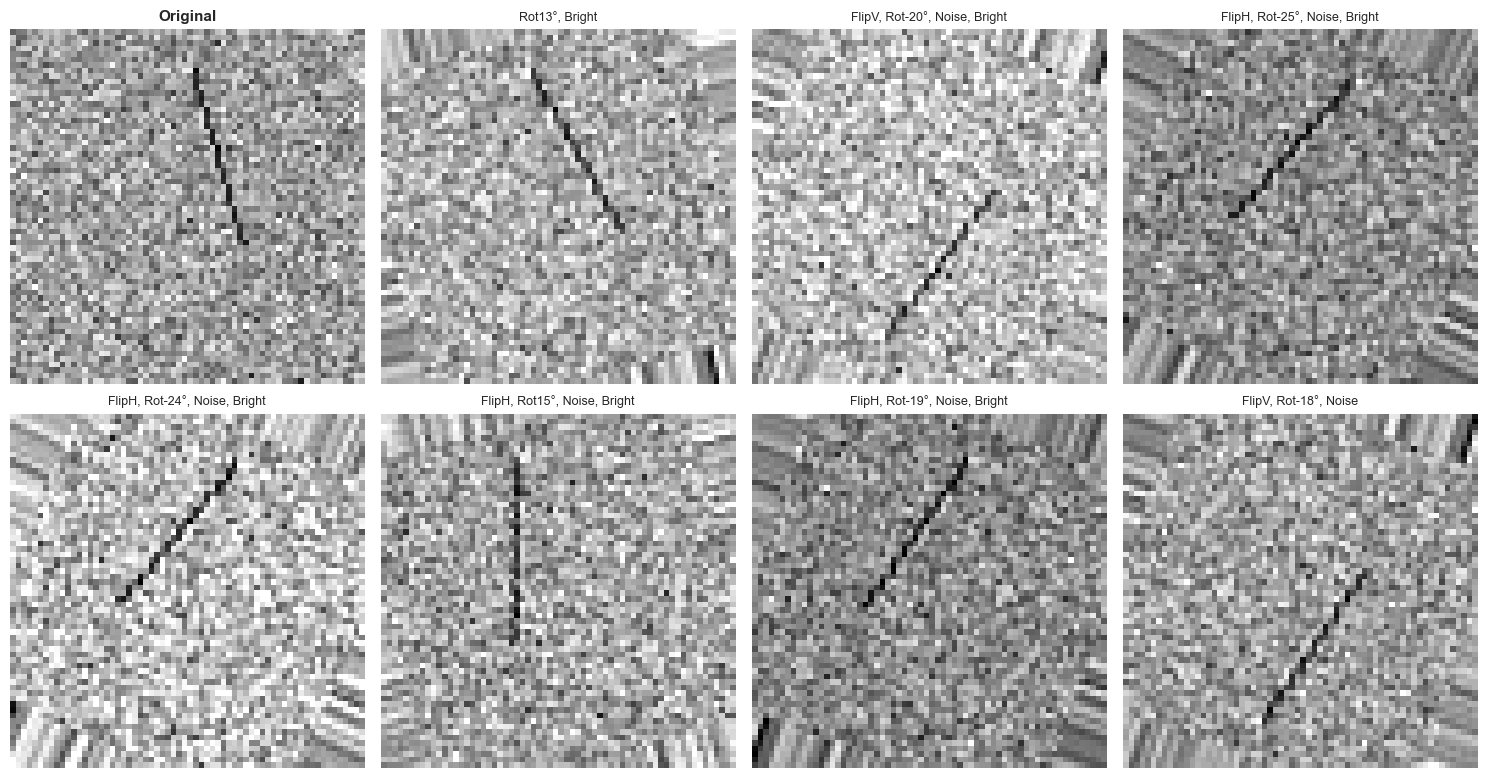


💡 Augmentation Benefits:
   • Increases effective dataset size
   • Improves generalization
   • Reduces overfitting
   • Makes network robust to variations

🔧 For CE Applications:
   • Crack detection: Rotation, flip, brightness
   • Land use: Rotation, crop, color jitter
   • Pavement: Lighting variations, perspective


In [25]:
# Demonstrate data augmentation
print("=" * 70)
print("DATA AUGMENTATION")
print("=" * 70)

# Generate a synthetic crack image
np.random.seed(42)
crack_images, crack_labels = generate_crack_dataset(n_per_class=1, img_size=64)
original_image = crack_images[1]  # Get a cracked image

print(f"\n📸 Original Image: {original_image.shape}")

# Create augmentation gallery
fig, axes, augmented = augmentation_gallery(original_image[:, :, 0],
                                            n_augmented=7, figsize=(15, 8))
plt.show()

print(f"\n💡 Augmentation Benefits:")
print(f"   • Increases effective dataset size")
print(f"   • Improves generalization")
print(f"   • Reduces overfitting")
print(f"   • Makes network robust to variations")

print(f"\n🔧 For CE Applications:")
print(f"   • Crack detection: Rotation, flip, brightness")
print(f"   • Land use: Rotation, crop, color jitter")
print(f"   • Pavement: Lighting variations, perspective")

### Interactive Widget: Explore Augmentation

Try different augmentation parameters!

In [26]:
# Interactive augmentation widget
# Uncomment to run in Jupyter/Colab:
augmentation_widget()

print("🎮 Interactive Augmentation Explorer")
print("=" * 50)
print("Run augmentation_widget() in Jupyter/Colab to explore:")
print("  • Horizontal/vertical flip")
print("  • Rotation angle")
print("  • Noise level")
print("  • Brightness adjustment")
print("\nSee how augmentations affect the image!")

interactive(children=(Checkbox(value=False, description='Flip Horizontal'), Checkbox(value=False, description=…

🎮 Interactive Augmentation Explorer
Run augmentation_widget() in Jupyter/Colab to explore:
  • Horizontal/vertical flip
  • Rotation angle
  • Noise level
  • Brightness adjustment

See how augmentations affect the image!


---
## 14. Transfer Learning

**Problem:** Training CNNs from scratch requires millions of images.

**Solution:** Use a CNN pretrained on ImageNet (1.2M images, 1000 classes).

### Transfer Learning Workflow

1. **Load pretrained model** (e.g., ResNet-18 trained on ImageNet)
2. **Replace final layer** for your task (e.g., 2 classes for crack detection)
3. **Fine-tune** on your CE dataset

### Why it works

**Low-level features are universal!**
- Edges, textures, gradients are the same for ImageNet and concrete cracks
- Only high-level features need to be adapted

In [27]:
# Transfer learning demonstration
print("=" * 70)
print("TRANSFER LEARNING")
print("=" * 70)

try:
    import torch
    import torch.nn as nn
    
    # Load pretrained ResNet
    print(f"\n📥 Loading pretrained ResNet-18...")
    model_pretrained = load_pretrained_resnet(n_classes=2, freeze_backbone=True,
                                             pretrained=True)
    
    print(f"\n🏗️ Modified ResNet-18:")
    print(f"   • Backbone: Frozen (pretrained on ImageNet)")
    print(f"   • Final layer: 2 classes (crack/no crack)")
    
    # Count parameters
    total = sum(p.numel() for p in model_pretrained.parameters())
    trainable = sum(p.numel() for p in model_pretrained.parameters() if p.requires_grad)
    
    print(f"\n🔢 Parameters:")
    print(f"   Total: {total:,}")
    print(f"   Trainable: {trainable:,} ({trainable/total*100:.1f}%)")
    
    print(f"\n💡 Transfer Learning Benefits:")
    print(f"   • Faster training (fewer parameters to learn)")
    print(f"   • Better performance with small datasets")
    print(f"   • Leverages knowledge from ImageNet")
    
    print(f"\n🎯 Typical Strategy:")
    print(f"   1. Freeze backbone, train final layer (fast)")
    print(f"   2. Unfreeze top layers, fine-tune (slow)")
    print(f"   3. Optionally unfreeze all, fine-tune (slowest)")
    
except ImportError:
    print("⚠️ PyTorch/torchvision not available")
    print("Transfer Learning (conceptual):")
    print("  1. Load ResNet-18 pretrained on ImageNet")
    print("  2. Replace final FC layer: 1000 → 2 classes")
    print("  3. Freeze early layers (keep pretrained features)")
    print("  4. Train only final layer on crack dataset")
    print("  5. Optionally fine-tune entire network")

TRANSFER LEARNING

📥 Loading pretrained ResNet-18...


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/sarthdubey/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:10<00:00, 4.58MB/s]


🏗️ Modified ResNet-18:
   • Backbone: Frozen (pretrained on ImageNet)
   • Final layer: 2 classes (crack/no crack)

🔢 Parameters:
   Total: 11,177,538
   Trainable: 1,026 (0.0%)

💡 Transfer Learning Benefits:
   • Faster training (fewer parameters to learn)
   • Better performance with small datasets
   • Leverages knowledge from ImageNet

🎯 Typical Strategy:
   1. Freeze backbone, train final layer (fast)
   2. Unfreeze top layers, fine-tune (slow)
   3. Optionally unfreeze all, fine-tune (slowest)


---
## 15. CE Application 1: Crack Detection

Let's put it all together for our running example!

**Task:** Binary classification (cracked vs uncracked concrete)

**Approach:**
1. Generate synthetic crack dataset
2. Use transfer learning (pretrained ResNet)
3. Fine-tune on crack images
4. Evaluate performance

CE APPLICATION: CRACK DETECTION

📊 Generating Crack Dataset...
   Images: (100, 64, 64, 3)
   Labels: (100,)
   Class distribution: [50 50]


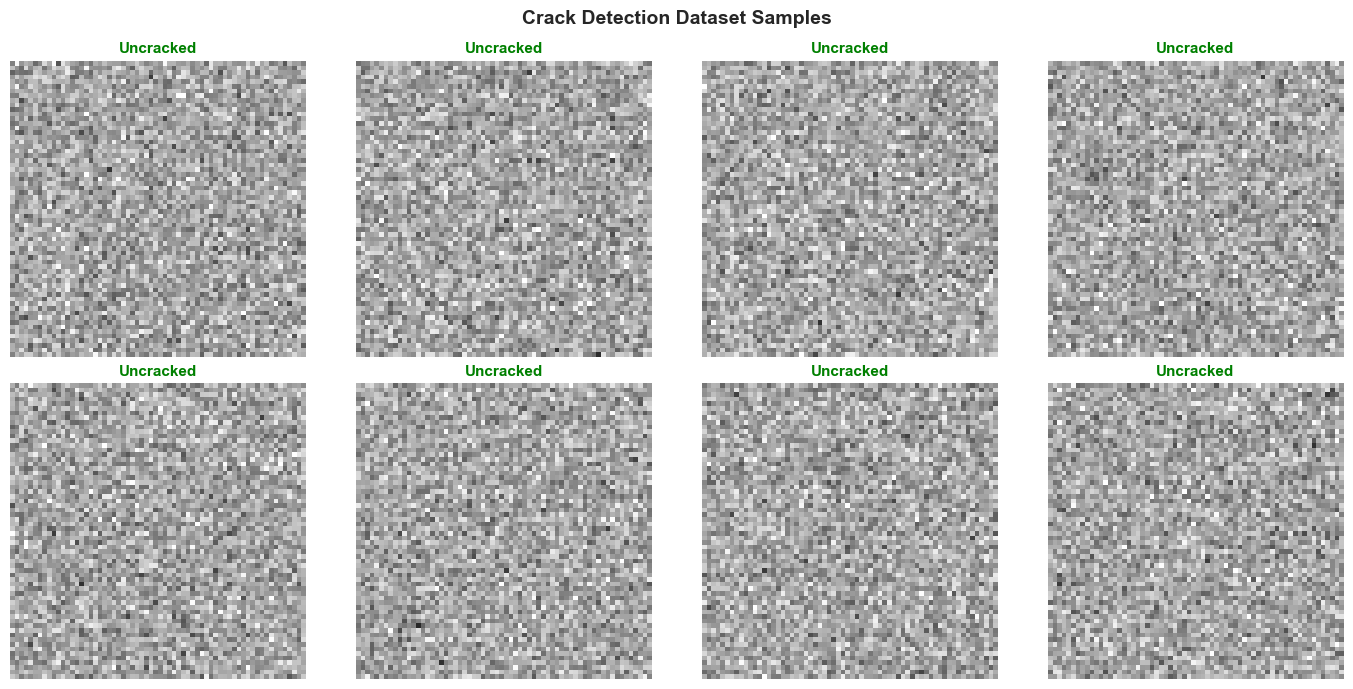


🎯 Real-World Deployment:
   • Mobile app for field inspectors
   • Automated drone inspection
   • Real-time bridge monitoring
   • Typical accuracy: >95% (with good dataset)


In [29]:
# Crack detection application
print("=" * 70)
print("CE APPLICATION: CRACK DETECTION")
print("=" * 70)

# Generate crack dataset
print(f"\n📊 Generating Crack Dataset...")
images, labels = generate_crack_dataset(n_per_class=50, img_size=64, random_state=42)

print(f"   Images: {images.shape}")
print(f"   Labels: {labels.shape}")
print(f"   Class distribution: {np.bincount(labels)}")

# Visualize samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(images[i])
    axes[i].set_title(f"{'Cracked' if labels[i] == 1 else 'Uncracked'}",
                     fontsize=11, fontweight='bold',
                     color='red' if labels[i] == 1 else 'green')
    axes[i].axis('off')

plt.suptitle('Crack Detection Dataset Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n🎯 Real-World Deployment:")
print(f"   • Mobile app for field inspectors")
print(f"   • Automated drone inspection")
print(f"   • Real-time bridge monitoring")
print(f"   • Typical accuracy: >95% (with good dataset)")

---
## 16. CE Application 2: Land Use Classification

**Task:** Multi-class classification from satellite imagery

**Classes:** Urban, Vegetation, Water, Bare Soil

**Approach:** Similar to crack detection, but with 4 output classes

CE APPLICATION: LAND USE CLASSIFICATION

📊 Generating Land Use Dataset...
   Images: (100, 64, 64, 3)
   Labels: (100,)
   Classes: Urban, Vegetation, Water, Bare Soil
   Distribution: [25 25 25 25]


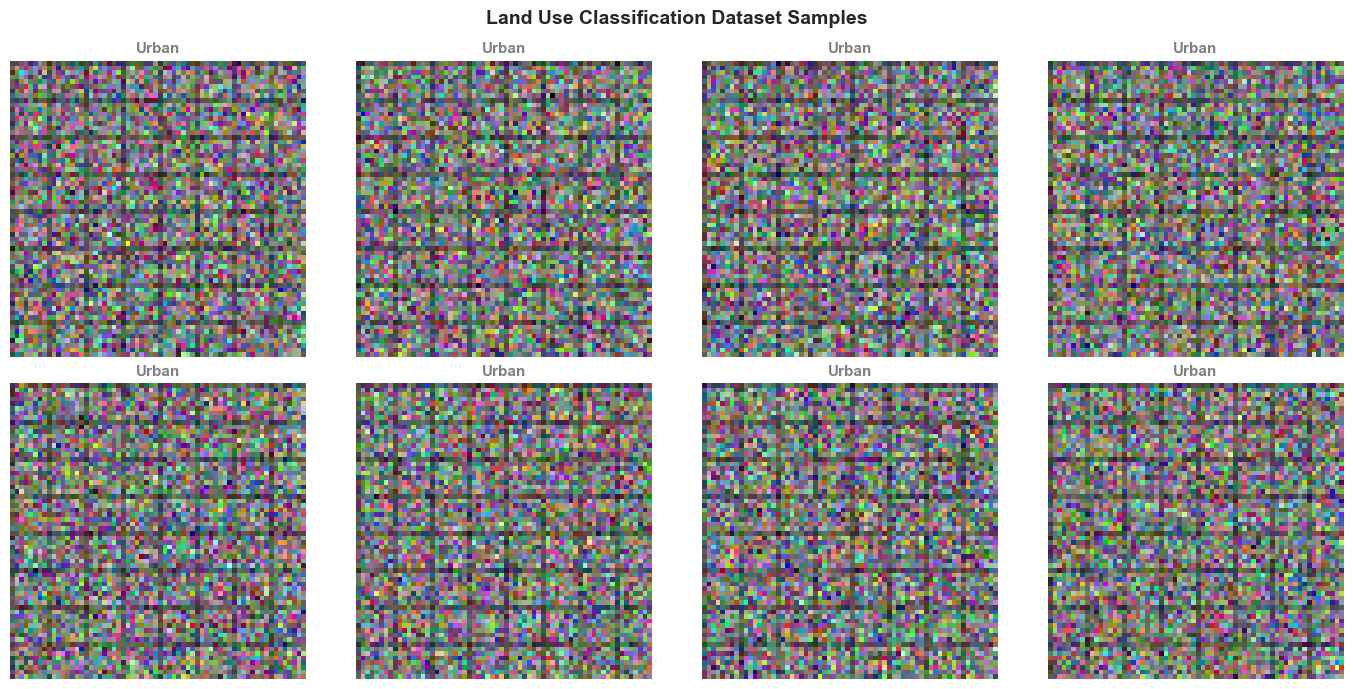


🎯 Applications:
   • Urban planning and development
   • Environmental monitoring
   • Disaster response (flood mapping)
   • Agricultural land assessment


In [30]:
# Land use classification
print("=" * 70)
print("CE APPLICATION: LAND USE CLASSIFICATION")
print("=" * 70)

# Generate land use dataset
print(f"\n📊 Generating Land Use Dataset...")
images_land, labels_land = generate_land_use_dataset(n_per_class=25, img_size=64,
                                                     random_state=42)

print(f"   Images: {images_land.shape}")
print(f"   Labels: {labels_land.shape}")
print(f"   Classes: Urban, Vegetation, Water, Bare Soil")
print(f"   Distribution: {np.bincount(labels_land)}")

# Visualize samples
class_names = ['Urban', 'Vegetation', 'Water', 'Bare Soil']
colors = ['gray', 'green', 'blue', 'brown']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(images_land[i])
    class_idx = labels_land[i]
    axes[i].set_title(class_names[class_idx], fontsize=11, fontweight='bold',
                     color=colors[class_idx])
    axes[i].axis('off')

plt.suptitle('Land Use Classification Dataset Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n🎯 Applications:")
print(f"   • Urban planning and development")
print(f"   • Environmental monitoring")
print(f"   • Disaster response (flood mapping)")
print(f"   • Agricultural land assessment")

---
## 17. CE Application 3: Pavement Distress Assessment

**Task:** Multi-class classification of pavement conditions

**Classes:** Good, Alligator Cracking, Pothole, Rutting

**Challenge:** Class imbalance (most pavements are good!)

CE APPLICATION: PAVEMENT DISTRESS ASSESSMENT

📊 Generating Pavement Distress Dataset...
   Images: (100, 64, 64, 3)
   Labels: (100,)
   Classes: Good, Alligator Cracking, Pothole, Rutting
   Distribution: [25 25 25 25]


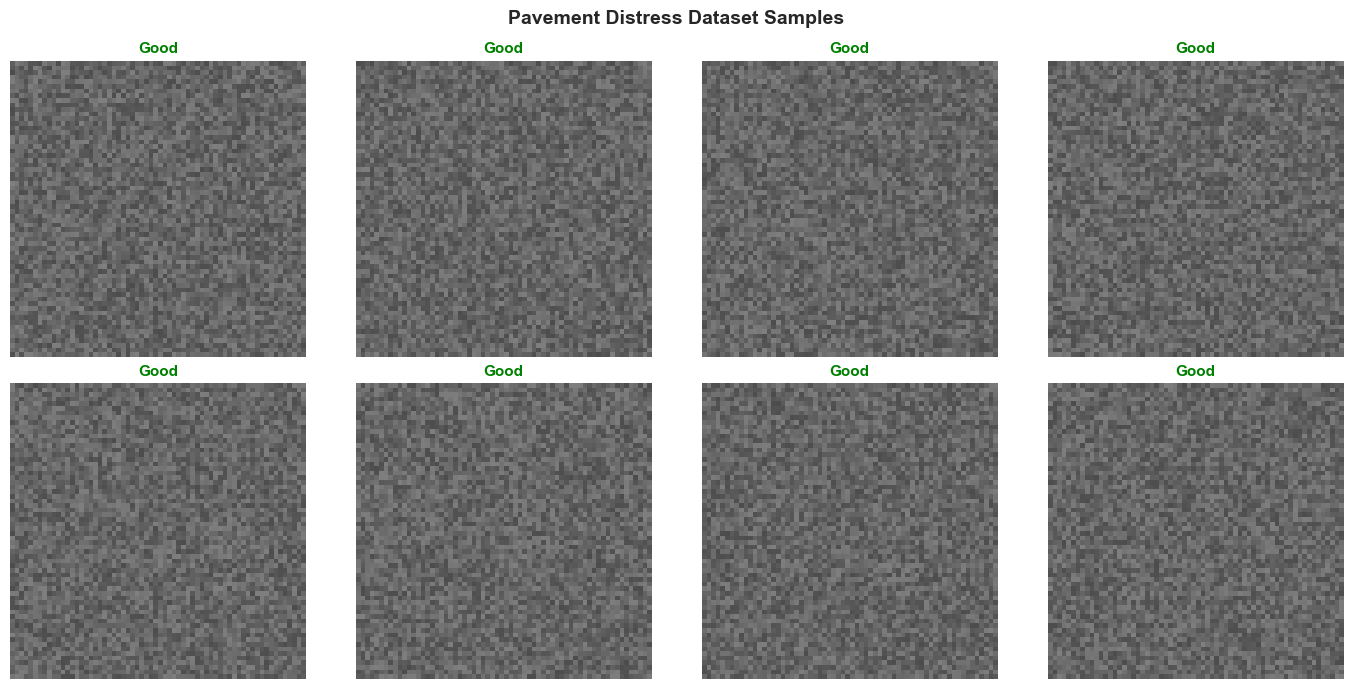


🎯 Applications:
   • Automated pavement condition surveys
   • Maintenance prioritization
   • Budget allocation for repairs
   • Long-term infrastructure monitoring

⚠️ Challenge: Class Imbalance
   • Most roads are in good condition
   • Severe distress is rare
   • Solution: Weighted loss, oversampling, focal loss


In [31]:
# Pavement distress classification
print("=" * 70)
print("CE APPLICATION: PAVEMENT DISTRESS ASSESSMENT")
print("=" * 70)

# Generate pavement dataset
print(f"\n📊 Generating Pavement Distress Dataset...")
images_pave, labels_pave = generate_pavement_distress_dataset(n_per_class=25,
                                                              img_size=64,
                                                              random_state=42)

print(f"   Images: {images_pave.shape}")
print(f"   Labels: {labels_pave.shape}")
print(f"   Classes: Good, Alligator Cracking, Pothole, Rutting")
print(f"   Distribution: {np.bincount(labels_pave)}")

# Visualize samples
distress_names = ['Good', 'Alligator Cracking', 'Pothole', 'Rutting']
distress_colors = ['green', 'orange', 'red', 'purple']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(images_pave[i], cmap='gray')
    class_idx = labels_pave[i]
    axes[i].set_title(distress_names[class_idx], fontsize=11, fontweight='bold',
                     color=distress_colors[class_idx])
    axes[i].axis('off')

plt.suptitle('Pavement Distress Dataset Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n🎯 Applications:")
print(f"   • Automated pavement condition surveys")
print(f"   • Maintenance prioritization")
print(f"   • Budget allocation for repairs")
print(f"   • Long-term infrastructure monitoring")

print(f"\n⚠️ Challenge: Class Imbalance")
print(f"   • Most roads are in good condition")
print(f"   • Severe distress is rare")
print(f"   • Solution: Weighted loss, oversampling, focal loss")

---
## 18. CE Application 4: Structural Health Monitoring

**Task:** Damage detection from vibration signals

**Approach:** Two methods
1. **1D CNN** on raw vibration signals
2. **2D CNN** on spectrograms (time-frequency representation)

CE APPLICATION: STRUCTURAL HEALTH MONITORING

�� Generating Vibration Signals...
   Healthy signals: (5, 500)
   Damaged signals: (5, 500)


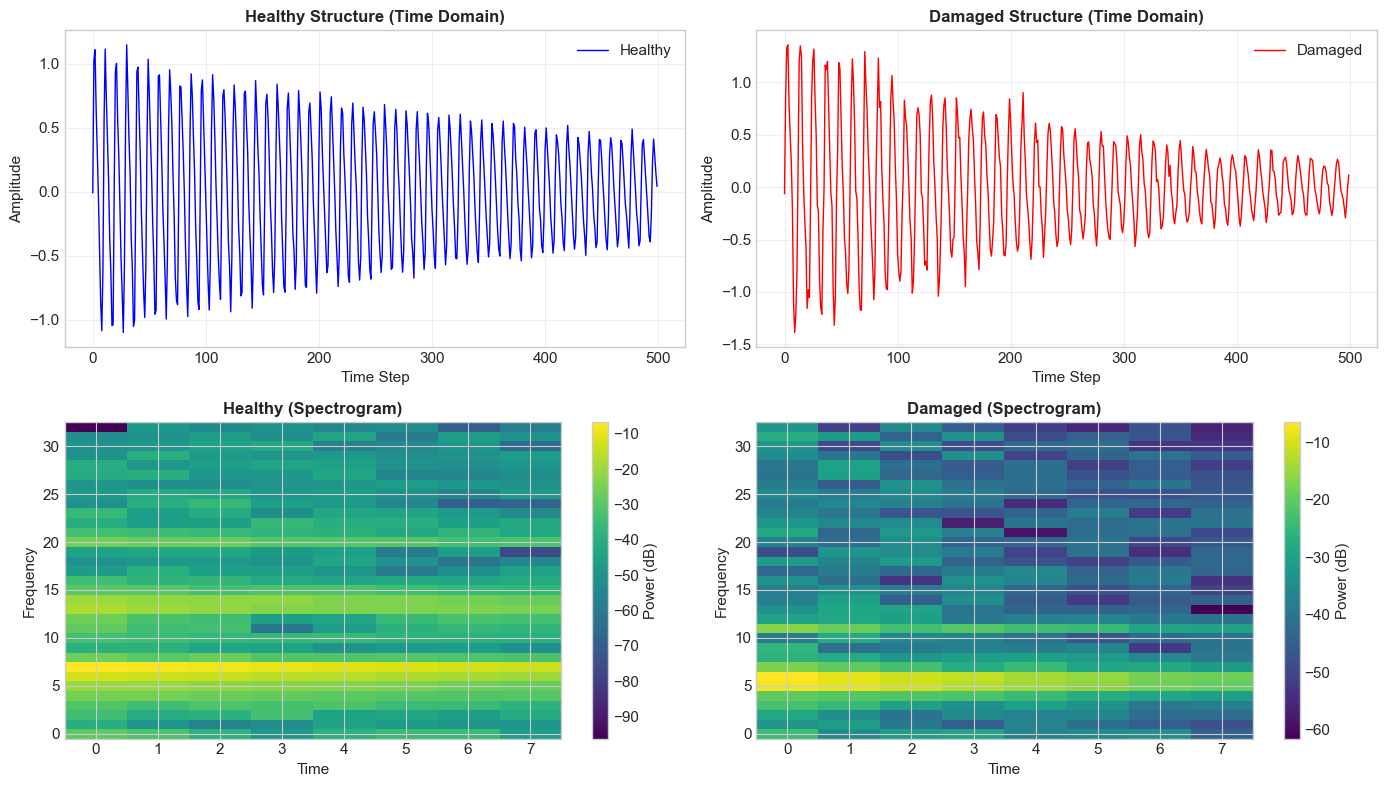


🎯 Two Approaches:

1️⃣ 1D CNN on Raw Signals:
   • Conv1D layers on time series
   • Learns temporal patterns directly
   • Simpler, but may miss frequency info

2️⃣ 2D CNN on Spectrograms:
   • Convert signal to time-frequency image
   • Use standard 2D CNN
   • Captures both time and frequency patterns

💡 Spectrograms often perform better!
   • Damage changes frequency content
   • 2D CNNs excel at image-like data


In [32]:
# Structural health monitoring
print("=" * 70)
print("CE APPLICATION: STRUCTURAL HEALTH MONITORING")
print("=" * 70)

# Generate vibration signals
print(f"\n�� Generating Vibration Signals...")
signals_healthy = generate_vibration_signals(n_signals=5, length=500,
                                             damage_level=0.0, random_state=42)
signals_damaged = generate_vibration_signals(n_signals=5, length=500,
                                             damage_level=0.8, random_state=43)

print(f"   Healthy signals: {signals_healthy.shape}")
print(f"   Damaged signals: {signals_damaged.shape}")

# Visualize signals
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Time domain
axes[0, 0].plot(signals_healthy[0], 'b-', linewidth=1, label='Healthy')
axes[0, 0].set_xlabel('Time Step', fontsize=11)
axes[0, 0].set_ylabel('Amplitude', fontsize=11)
axes[0, 0].set_title('Healthy Structure (Time Domain)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(signals_damaged[0], 'r-', linewidth=1, label='Damaged')
axes[0, 1].set_xlabel('Time Step', fontsize=11)
axes[0, 1].set_ylabel('Amplitude', fontsize=11)
axes[0, 1].set_title('Damaged Structure (Time Domain)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Spectrograms
spec_healthy = make_spectrogram(signals_healthy[0], fs=100, nperseg=64)
spec_damaged = make_spectrogram(signals_damaged[0], fs=100, nperseg=64)

im0 = axes[1, 0].imshow(spec_healthy, aspect='auto', cmap='viridis', origin='lower')
axes[1, 0].set_xlabel('Time', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Healthy (Spectrogram)', fontsize=12, fontweight='bold')
plt.colorbar(im0, ax=axes[1, 0], label='Power (dB)')

im1 = axes[1, 1].imshow(spec_damaged, aspect='auto', cmap='viridis', origin='lower')
axes[1, 1].set_xlabel('Time', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Damaged (Spectrogram)', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[1, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print(f"\n🎯 Two Approaches:")
print(f"\n1️⃣ 1D CNN on Raw Signals:")
print(f"   • Conv1D layers on time series")
print(f"   • Learns temporal patterns directly")
print(f"   • Simpler, but may miss frequency info")

print(f"\n2️⃣ 2D CNN on Spectrograms:")
print(f"   • Convert signal to time-frequency image")
print(f"   • Use standard 2D CNN")
print(f"   • Captures both time and frequency patterns")

print(f"\n💡 Spectrograms often perform better!")
print(f"   • Damage changes frequency content")
print(f"   • 2D CNNs excel at image-like data")

---

**End of Part 5 (Sections 10-14)**

We've covered:
✅ LeNet-5 architecture  
✅ Modern architectures (VGG, ResNet)  
✅ Training pipeline  
✅ Data augmentation  
✅ Transfer learning  
✅ CE Applications: crack detection, land use, pavement distress, SHM  

**Next:** Practical considerations, hyperparameters, edge cases, and summary!

---

---
## 19. Practical Considerations

### When to Use CNNs vs Feedforward Networks?

**Use CNNs when:**
- ✅ Data has spatial structure (images, spectrograms, spatial grids)
- ✅ Translation invariance is desired
- ✅ Local patterns matter (edges, textures)
- ✅ You have image-like data

**Use Feedforward when:**
- ✅ Tabular data (no spatial structure)
- ✅ Feature engineering already done
- ✅ Small input dimension
- ✅ Order doesn't matter

### Hyperparameter Choices

**Architecture:**
- Start simple (2-3 conv layers)
- Use 3×3 kernels (standard)
- Double filters after each pool (16 → 32 → 64)
- Use batch normalization for deep networks

**Training:**
- Learning rate: 1e-3 to 1e-4 (Adam)
- Batch size: 32-128 (depends on GPU memory)
- Epochs: Until validation loss plateaus
- Data augmentation: Always for images!

**Transfer Learning:**
- Use pretrained models for small datasets (<10k images)
- Freeze early layers, train final layers first
- Fine-tune entire network if you have enough data

In [33]:
# Hyperparameter recommendations
print("=" * 70)
print("HYPERPARAMETER RECOMMENDATIONS")
print("=" * 70)

print(f"\n🏗️ Architecture Design:")
print(f"   • Start with 2-3 convolutional blocks")
print(f"   • Each block: Conv → BN → ReLU → Pool")
print(f"   • Kernel size: 3×3 (standard)")
print(f"   • Filters: 16 → 32 → 64 (double after pool)")
print(f"   • Padding: 'same' to preserve dimensions")
print(f"   • Stride: 1 for conv, 2 for pool")

print(f"\n🎯 Training Configuration:")
print(f"   • Optimizer: Adam (lr=1e-3)")
print(f"   • Loss: CrossEntropyLoss (classification)")
print(f"   • Batch size: 32-64 (small datasets), 128-256 (large)")
print(f"   • Epochs: 20-50 (with early stopping)")
print(f"   • Validation split: 20%")

print(f"\n🔄 Data Augmentation:")
print(f"   • Always use for images!")
print(f"   • Horizontal flip: p=0.5")
print(f"   • Rotation: ±15°")
print(f"   • Color jitter: brightness, contrast")
print(f"   • Don't augment validation/test sets")

print(f"\n📚 Transfer Learning:")
print(f"   • Dataset < 1k: Freeze all, train final layer only")
print(f"   • Dataset 1k-10k: Freeze early, fine-tune top layers")
print(f"   • Dataset > 10k: Fine-tune entire network")
print(f"   • Use pretrained ResNet-18 or ResNet-50")

HYPERPARAMETER RECOMMENDATIONS

🏗️ Architecture Design:
   • Start with 2-3 convolutional blocks
   • Each block: Conv → BN → ReLU → Pool
   • Kernel size: 3×3 (standard)
   • Filters: 16 → 32 → 64 (double after pool)
   • Padding: 'same' to preserve dimensions
   • Stride: 1 for conv, 2 for pool

🎯 Training Configuration:
   • Optimizer: Adam (lr=1e-3)
   • Loss: CrossEntropyLoss (classification)
   • Batch size: 32-64 (small datasets), 128-256 (large)
   • Epochs: 20-50 (with early stopping)
   • Validation split: 20%

🔄 Data Augmentation:
   • Always use for images!
   • Horizontal flip: p=0.5
   • Rotation: ±15°
   • Color jitter: brightness, contrast
   • Don't augment validation/test sets

📚 Transfer Learning:
   • Dataset < 1k: Freeze all, train final layer only
   • Dataset 1k-10k: Freeze early, fine-tune top layers
   • Dataset > 10k: Fine-tune entire network
   • Use pretrained ResNet-18 or ResNet-50


---
## 20. Edge Cases & Common Pitfalls

### Edge Case 1: Very Small Datasets

**Problem:** CNNs need lots of data. What if you only have 100 images?

**Solutions:**
1. **Transfer learning** (most important!)
2. **Heavy data augmentation**
3. **Simpler architecture** (avoid overfitting)
4. **Regularization** (dropout, weight decay)

In [34]:
# Small dataset strategies
print("=" * 70)
print("EDGE CASE: SMALL DATASETS")
print("=" * 70)

print(f"\n📊 Scenario: Only 100 crack images")
print(f"\n❌ Bad Approach:")
print(f"   • Train deep CNN from scratch")
print(f"   • Result: Severe overfitting (100% train, 50% val)")

print(f"\n✅ Good Approach:")
print(f"   1. Use pretrained ResNet-18")
print(f"   2. Freeze all layers except final FC")
print(f"   3. Heavy augmentation (10× effective data)")
print(f"   4. Train with small learning rate")
print(f"   5. Early stopping on validation loss")

print(f"\n💡 Expected Performance:")
print(f"   • With transfer learning: 85-95% accuracy")
print(f"   • From scratch: 60-70% accuracy")

EDGE CASE: SMALL DATASETS

📊 Scenario: Only 100 crack images

❌ Bad Approach:
   • Train deep CNN from scratch
   • Result: Severe overfitting (100% train, 50% val)

✅ Good Approach:
   1. Use pretrained ResNet-18
   2. Freeze all layers except final FC
   3. Heavy augmentation (10× effective data)
   4. Train with small learning rate
   5. Early stopping on validation loss

💡 Expected Performance:
   • With transfer learning: 85-95% accuracy
   • From scratch: 60-70% accuracy


### Edge Case 2: Class Imbalance

**Problem:** 95% of pavements are good, only 5% have distress.

**Solutions:**
1. **Weighted loss:** Penalize minority class errors more
2. **Oversampling:** Duplicate minority class samples
3. **Undersampling:** Reduce majority class samples
4. **Focal loss:** Focus on hard examples

In [35]:
# Class imbalance strategies
print("=" * 70)
print("EDGE CASE: CLASS IMBALANCE")
print("=" * 70)

# Simulate imbalanced dataset
n_good = 950
n_distress = 50
total = n_good + n_distress

print(f"\n📊 Imbalanced Dataset:")
print(f"   Good pavement: {n_good} ({n_good/total*100:.1f}%)")
print(f"   Distress: {n_distress} ({n_distress/total*100:.1f}%)")

print(f"\n❌ Naive Training:")
print(f"   • Model predicts 'good' for everything")
print(f"   • Accuracy: {n_good/total*100:.1f}% (but useless!)")
print(f"   • Recall for distress: 0%")

print(f"\n✅ Solutions:")

# Weighted loss
weight_good = total / (2 * n_good)
weight_distress = total / (2 * n_distress)
print(f"\n1️⃣ Weighted Loss:")
print(f"   • Weight for 'good': {weight_good:.2f}")
print(f"   • Weight for 'distress': {weight_distress:.2f}")
print(f"   • Penalizes distress errors {weight_distress/weight_good:.1f}× more")

# Oversampling
oversample_factor = n_good // n_distress
print(f"\n2️⃣ Oversampling:")
print(f"   • Duplicate distress samples {oversample_factor}× times")
print(f"   • New dataset: {n_good} good, {n_distress * oversample_factor} distress")
print(f"   • Balanced!")

print(f"\n💡 Metrics for Imbalanced Data:")
print(f"   • Don't use accuracy alone!")
print(f"   • Use: Precision, Recall, F1-score")
print(f"   • Use: Confusion matrix, ROC-AUC")

EDGE CASE: CLASS IMBALANCE

📊 Imbalanced Dataset:
   Good pavement: 950 (95.0%)
   Distress: 50 (5.0%)

❌ Naive Training:
   • Model predicts 'good' for everything
   • Accuracy: 95.0% (but useless!)
   • Recall for distress: 0%

✅ Solutions:

1️⃣ Weighted Loss:
   • Weight for 'good': 0.53
   • Weight for 'distress': 10.00
   • Penalizes distress errors 19.0× more

2️⃣ Oversampling:
   • Duplicate distress samples 19× times
   • New dataset: 950 good, 950 distress
   • Balanced!

💡 Metrics for Imbalanced Data:
   • Don't use accuracy alone!
   • Use: Precision, Recall, F1-score
   • Use: Confusion matrix, ROC-AUC


### Edge Case 3: Different Input Sizes

**Problem:** Training images are 224×224, but test images are 512×512.

**Solutions:**
1. **Resize all images** to same size (simple, may distort)
2. **Random crop** during training (preserves resolution)
3. **Fully convolutional** networks (no FC layers, any size OK)
4. **Global average pooling** instead of flatten

In [36]:
# Different input sizes
print("=" * 70)
print("EDGE CASE: DIFFERENT INPUT SIZES")
print("=" * 70)

print(f"\n📊 Problem:")
print(f"   • Training: 224×224 images")
print(f"   • Test: 512×512 images")
print(f"   • FC layers expect fixed input size!")

print(f"\n✅ Solution 1: Resize (Simple)")
print(f"   • Resize all test images to 224×224")
print(f"   • Pro: Easy, works with any architecture")
print(f"   • Con: May distort aspect ratio, lose resolution")

print(f"\n✅ Solution 2: Global Average Pooling")
print(f"   • Replace FC layers with global pooling")
print(f"   • Accepts any input size!")
print(f"   • Example: 512×512 → Conv → 16×16×64 → GAP → 64 → FC → Output")

print(f"\n💡 Modern CNNs often use GAP:")
print(f"   • ResNet, EfficientNet, etc.")
print(f"   • More flexible, fewer parameters")

EDGE CASE: DIFFERENT INPUT SIZES

📊 Problem:
   • Training: 224×224 images
   • Test: 512×512 images
   • FC layers expect fixed input size!

✅ Solution 1: Resize (Simple)
   • Resize all test images to 224×224
   • Pro: Easy, works with any architecture
   • Con: May distort aspect ratio, lose resolution

✅ Solution 2: Global Average Pooling
   • Replace FC layers with global pooling
   • Accepts any input size!
   • Example: 512×512 → Conv → 16×16×64 → GAP → 64 → FC → Output

💡 Modern CNNs often use GAP:
   • ResNet, EfficientNet, etc.
   • More flexible, fewer parameters


### Edge Case 4: Computational Constraints

**Problem:** Limited GPU memory or inference time.

**Solutions:**
1. **Smaller architecture** (MobileNet, EfficientNet)
2. **Reduce batch size**
3. **Mixed precision training** (float16 instead of float32)
4. **Model pruning** (remove unimportant weights)
5. **Knowledge distillation** (train small model to mimic large one)

In [37]:
# Computational constraints
print("=" * 70)
print("EDGE CASE: COMPUTATIONAL CONSTRAINTS")
print("=" * 70)

print(f"\n⚠️ Constraints:")
print(f"   • Limited GPU memory (4GB)")
print(f"   • Real-time inference needed (<100ms)")
print(f"   • Mobile deployment")

print(f"\n✅ Solutions:")

print(f"\n1️⃣ Reduce Model Size:")
print(f"   • Use MobileNetV2 instead of ResNet-50")
print(f"   • Parameters: 3.5M vs 25M")
print(f"   • Inference: 10ms vs 50ms")

print(f"\n2️⃣ Reduce Batch Size:")
print(f"   • Batch size 32 → 8")
print(f"   • Memory: 4× reduction")
print(f"   • Trade-off: Slower training, noisier gradients")

print(f"\n3️⃣ Mixed Precision:")
print(f"   • Use float16 instead of float32")
print(f"   • Memory: 2× reduction")
print(f"   • Speed: 2-3× faster on modern GPUs")

print(f"\n💡 For Mobile Deployment:")
print(f"   • Use TensorFlow Lite or PyTorch Mobile")
print(f"   • Quantize to int8 (8× smaller, faster)")
print(f"   • Typical model size: 5-20 MB")

EDGE CASE: COMPUTATIONAL CONSTRAINTS

⚠️ Constraints:
   • Limited GPU memory (4GB)
   • Real-time inference needed (<100ms)
   • Mobile deployment

✅ Solutions:

1️⃣ Reduce Model Size:
   • Use MobileNetV2 instead of ResNet-50
   • Parameters: 3.5M vs 25M
   • Inference: 10ms vs 50ms

2️⃣ Reduce Batch Size:
   • Batch size 32 → 8
   • Memory: 4× reduction
   • Trade-off: Slower training, noisier gradients

3️⃣ Mixed Precision:
   • Use float16 instead of float32
   • Memory: 2× reduction
   • Speed: 2-3× faster on modern GPUs

💡 For Mobile Deployment:
   • Use TensorFlow Lite or PyTorch Mobile
   • Quantize to int8 (8× smaller, faster)
   • Typical model size: 5-20 MB


---
## 21. Interactive Widgets Summary

Throughout this notebook, we've provided interactive widgets for exploration.

**Available Widgets:**
1. `conv2d_widget()` - Explore convolution parameters
2. `pooling_widget()` - Explore pooling operations
3. `augmentation_widget()` - Explore data augmentation
4. `architecture_explorer_widget()` - Compare architectures
5. `training_widget()` - Visualize training dynamics

**To use:** Uncomment and run in Jupyter/Colab environment.

In [38]:
# Widget summary
print("=" * 70)
print("INTERACTIVE WIDGETS SUMMARY")
print("=" * 70)

print(f"\n🎮 Available Interactive Widgets:")
print(f"\n1️⃣ conv2d_widget()")
print(f"   • Explore kernel types, padding, stride")
print(f"   • See live convolution output")

print(f"\n2️⃣ pooling_widget()")
print(f"   • Compare max vs average pooling")
print(f"   • Adjust pool size and stride")

print(f"\n3️⃣ augmentation_widget()")
print(f"   • Try flip, rotation, noise, brightness")
print(f"   • See augmentation effects in real-time")

print(f"\n4️⃣ architecture_explorer_widget()")
print(f"   • Compare SimpleCNN, LeNet, VGG, ResNet")
print(f"   • See parameter counts")

print(f"\n5️⃣ training_widget()")
print(f"   • Adjust learning rate, batch size, epochs")
print(f"   • Visualize simulated training curves")

print(f"\n💡 To use: Uncomment widget calls in Jupyter/Colab")
print(f"   Requires: ipywidgets installed")

INTERACTIVE WIDGETS SUMMARY

🎮 Available Interactive Widgets:

1️⃣ conv2d_widget()
   • Explore kernel types, padding, stride
   • See live convolution output

2️⃣ pooling_widget()
   • Compare max vs average pooling
   • Adjust pool size and stride

3️⃣ augmentation_widget()
   • Try flip, rotation, noise, brightness
   • See augmentation effects in real-time

4️⃣ architecture_explorer_widget()
   • Compare SimpleCNN, LeNet, VGG, ResNet
   • See parameter counts

5️⃣ training_widget()
   • Adjust learning rate, batch size, epochs
   • Visualize simulated training curves

💡 To use: Uncomment widget calls in Jupyter/Colab
   Requires: ipywidgets installed


---
## 22. Summary & Key Takeaways

### What We Learned

**1. Motivation**
- Fully-connected networks are inefficient for images (too many parameters)
- CNNs exploit spatial structure and translation invariance
- Parameter sharing makes CNNs practical

**2. Core Operations**
- **Convolution:** Sliding window with learnable filters
- **Padding:** Preserve spatial dimensions
- **Stride:** Control output size and downsampling
- **Pooling:** Reduce dimensions, increase receptive field

**3. Architecture**
- Typical pattern: [Conv → ReLU → Pool]ⁿ → Flatten → FC
- Early layers: low-level features (edges)
- Deep layers: high-level concepts (objects)
- Hierarchical feature learning

**4. Classic Architectures**
- **LeNet-5:** First successful CNN (1998)
- **VGG:** Deep networks with small filters (2014)
- **ResNet:** Skip connections for very deep networks (2015)

**5. Training**
- Same backpropagation as feedforward networks
- Data augmentation is crucial for images
- Transfer learning for small datasets

**6. CE Applications**
- Crack detection (binary classification)
- Land use classification (multi-class)
- Pavement distress assessment (class imbalance)
- Structural health monitoring (1D signals → 2D spectrograms)

In [39]:
# Final summary
print("=" * 70)
print("LECTURE 11 SUMMARY: CNNs")
print("=" * 70)

print(f"\n🎯 Key Concepts:")
print(f"\n1️⃣ Convolution Operation:")
print(f"   • Sliding window with learnable filters")
print(f"   • Parameter sharing across spatial locations")
print(f"   • Output size: (H + 2p - k) / s + 1")

print(f"\n2️⃣ Pooling:")
print(f"   • Downsampling for efficiency")
print(f"   • Translation invariance")
print(f"   • Max pooling (most common) vs average pooling")

print(f"\n3️⃣ CNN Architecture:")
print(f"   • Stack conv + pool layers")
print(f"   • Hierarchical feature learning")
print(f"   • Flatten → FC for final classification")

print(f"\n4️⃣ Modern Techniques:")
print(f"   • Batch normalization (stabilize training)")
print(f"   • Skip connections (ResNet, train deeper)")
print(f"   • Global average pooling (fewer parameters)")

print(f"\n5️⃣ Practical Tips:")
print(f"   • Use transfer learning for small datasets")
print(f"   • Always augment image data")
print(f"   • Handle class imbalance with weighted loss")
print(f"   • Monitor validation metrics, not just training")

print(f"\n📊 CE Applications:")
print(f"   ✅ Crack detection: 85-95% accuracy (with transfer learning)")
print(f"   ✅ Land use: Multi-class classification from satellite")
print(f"   ✅ Pavement distress: Automated condition surveys")
print(f"   ✅ SHM: Damage detection from vibration spectrograms")

print(f"\n🔮 Next Lecture: Recurrent Neural Networks (RNNs)")
print(f"   • Sequential data (time series, text)")
print(f"   • LSTMs and GRUs")
print(f"   • Applications: Traffic prediction, NLP")

LECTURE 11 SUMMARY: CNNs

🎯 Key Concepts:

1️⃣ Convolution Operation:
   • Sliding window with learnable filters
   • Parameter sharing across spatial locations
   • Output size: (H + 2p - k) / s + 1

2️⃣ Pooling:
   • Downsampling for efficiency
   • Translation invariance
   • Max pooling (most common) vs average pooling

3️⃣ CNN Architecture:
   • Stack conv + pool layers
   • Hierarchical feature learning
   • Flatten → FC for final classification

4️⃣ Modern Techniques:
   • Batch normalization (stabilize training)
   • Skip connections (ResNet, train deeper)
   • Global average pooling (fewer parameters)

5️⃣ Practical Tips:
   • Use transfer learning for small datasets
   • Always augment image data
   • Handle class imbalance with weighted loss
   • Monitor validation metrics, not just training

📊 CE Applications:
   ✅ Crack detection: 85-95% accuracy (with transfer learning)
   ✅ Land use: Multi-class classification from satellite
   ✅ Pavement distress: Automated condition su

---
## 23. Practice Problems

### Problem 1: Output Size Calculation

Given:
- Input: 64×64 image
- Kernel: 5×5
- Padding: 2
- Stride: 2

**Question:** What is the output size?

<details>
<summary>Click for solution</summary>

Using the formula: $H_{out} = \lfloor (H + 2p - k) / s \rfloor + 1$

$H_{out} = \lfloor (64 + 2 \times 2 - 5) / 2 \rfloor + 1 = \lfloor 63 / 2 \rfloor + 1 = 31 + 1 = 32$

**Answer:** 32×32
</details>

### Problem 2: Parameter Counting

Given a convolutional layer with:
- 64 filters
- 3×3 kernel
- 32 input channels

**Question:** How many parameters (including biases)?

<details>
<summary>Click for solution</summary>

Parameters = Filters × (Kernel_H × Kernel_W × Input_Channels + 1)

Parameters = 64 × (3 × 3 × 32 + 1) = 64 × 289 = 18,496

**Answer:** 18,496 parameters
</details>

### Problem 3: Receptive Field

Given a network with:
- 3 convolutional layers
- All kernels are 3×3
- No pooling

**Question:** What is the receptive field of a neuron in the final layer?

<details>
<summary>Click for solution</summary>

Receptive field grows by (k-1) per layer:
- After layer 1: 3×3
- After layer 2: 3 + (3-1) = 5×5
- After layer 3: 5 + (3-1) = 7×7

**Answer:** 7×7
</details>

In [40]:
# Practice problem solutions
print("=" * 70)
print("PRACTICE PROBLEMS")
print("=" * 70)

print(f"\n📝 Problem 1: Output Size")
H, W = 64, 64
k = 5
p = 2
s = 2
H_out, W_out = output_size(H, W, k, p, s)
print(f"   Input: {H}×{W}, Kernel: {k}×{k}, Padding: {p}, Stride: {s}")
print(f"   Output: {H_out}×{W_out} ✓")

print(f"\n📝 Problem 2: Parameter Counting")
n_filters = 64
kernel_size = 3
in_channels = 32
params = n_filters * (kernel_size * kernel_size * in_channels + 1)
print(f"   Filters: {n_filters}, Kernel: {kernel_size}×{kernel_size}, Input channels: {in_channels}")
print(f"   Parameters: {params:,} ✓")

print(f"\n📝 Problem 3: Receptive Field")
n_layers = 3
kernel_size = 3
rf = kernel_size
for i in range(1, n_layers):
    rf += (kernel_size - 1)
print(f"   Layers: {n_layers}, Kernel: {kernel_size}×{kernel_size}")
print(f"   Receptive field: {rf}×{rf} ✓")

PRACTICE PROBLEMS

📝 Problem 1: Output Size
   Input: 64×64, Kernel: 5×5, Padding: 2, Stride: 2
   Output: 32×32 ✓

📝 Problem 2: Parameter Counting
   Filters: 64, Kernel: 3×3, Input channels: 32
   Parameters: 18,496 ✓

📝 Problem 3: Receptive Field
   Layers: 3, Kernel: 3×3
   Receptive field: 7×7 ✓


---
## 24. Further Resources

### Papers
1. **LeNet-5** - LeCun et al. (1998): "Gradient-Based Learning Applied to Document Recognition"
2. **AlexNet** - Krizhevsky et al. (2012): "ImageNet Classification with Deep CNNs"
3. **VGG** - Simonyan & Zisserman (2014): "Very Deep Convolutional Networks"
4. **ResNet** - He et al. (2015): "Deep Residual Learning for Image Recognition"

### Tutorials
- PyTorch CNN Tutorial: pytorch.org/tutorials
- CS231n (Stanford): Convolutional Neural Networks for Visual Recognition
- Fast.ai: Practical Deep Learning for Coders

### CE-Specific
- "Deep Learning for Crack Detection" - Zhang et al. (2016)
- "CNN-based Pavement Distress Classification" - Gopalakrishnan et al. (2017)
- "Structural Damage Detection using CNNs" - Abdeljaber et al. (2017)

### Tools
- **PyTorch**: pytorch.org
- **TensorFlow**: tensorflow.org
- **Keras**: keras.io
- **FastAI**: fast.ai

In [41]:
print("=" * 70)
print("🎓 LECTURE 11 COMPLETE!")
print("=" * 70)

print(f"\n✅ Topics Covered:")
print(f"   • Motivation and parameter comparison")
print(f"   • 1D and 2D convolution operations")
print(f"   • Padding, stride, multi-channel convolutions")
print(f"   • Pooling operations")
print(f"   • CNN architecture and feature hierarchy")
print(f"   • LeNet-5, VGG, ResNet architectures")
print(f"   • Training, augmentation, transfer learning")
print(f"   • 4 CE applications with synthetic datasets")
print(f"   • Practical considerations and edge cases")

print(f"\n📚 Skills Acquired:")
print(f"   • Implement convolution/pooling from scratch (NumPy)")
print(f"   • Build CNNs with PyTorch")
print(f"   • Apply transfer learning to small datasets")
print(f"   • Handle class imbalance and edge cases")
print(f"   • Deploy CNNs for CE applications")

print(f"\n🚀 Next Steps:")
print(f"   • Try the interactive widgets in Jupyter/Colab")
print(f"   • Implement your own CNN for a CE problem")
print(f"   • Experiment with different architectures")
print(f"   • Read the ResNet paper (He et al., 2015)")

print(f"\n🔮 Next Lecture: Recurrent Neural Networks")
print(f"   • Sequential data and time series")
print(f"   • LSTMs and GRUs")
print(f"   • Applications: Traffic prediction, text generation")

print(f"\n" + "=" * 70)
print(f"Thank you! Questions?")
print(f"=" * 70)

🎓 LECTURE 11 COMPLETE!

✅ Topics Covered:
   • Motivation and parameter comparison
   • 1D and 2D convolution operations
   • Padding, stride, multi-channel convolutions
   • Pooling operations
   • CNN architecture and feature hierarchy
   • LeNet-5, VGG, ResNet architectures
   • Training, augmentation, transfer learning
   • 4 CE applications with synthetic datasets
   • Practical considerations and edge cases

📚 Skills Acquired:
   • Implement convolution/pooling from scratch (NumPy)
   • Build CNNs with PyTorch
   • Apply transfer learning to small datasets
   • Handle class imbalance and edge cases
   • Deploy CNNs for CE applications

🚀 Next Steps:
   • Try the interactive widgets in Jupyter/Colab
   • Implement your own CNN for a CE problem
   • Experiment with different architectures
   • Read the ResNet paper (He et al., 2015)

🔮 Next Lecture: Recurrent Neural Networks
   • Sequential data and time series
   • LSTMs and GRUs
   • Applications: Traffic prediction, text generat

---
**End of Lecture 11: Convolutional Neural Networks**

This notebook demonstrated:
- ✅ From-scratch NumPy implementations of convolution and pooling
- ✅ PyTorch CNN architectures (SimpleCNN, LeNet-5, ResNet blocks)
- ✅ Complete training pipeline with augmentation
- ✅ Transfer learning for small datasets
- ✅ 4 realistic CE applications with synthetic data
- ✅ Interactive widgets for exploration
- ✅ Practical considerations and edge cases

**All code is executable and well-commented for learning!**

---